In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/ablation_all_results.csv'

Mounted at /content/drive


In [ ]:
import os

zip_file_path = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip'
destination_path = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Unzip the file
!unzip -q "{zip_file_path}" -d "{destination_path}"

print(f"Successfully unzipped {zip_file_path} to {destination_path}")

replace /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights/resnet18_cifar10_ft.pth? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Successfully unzipped /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip to /content/drive/MyDrive/unlearning_project/ARTIFACTS/


In [ ]:
# ============================================================
# ABLATION v2 — PS-PCGrad + Baselines (GA, Linear, PCGrad)
# Changes vs v1:
#   • Best-epoch tracking (saves best model mid-run)
#   • Append-safe CSV (multiple runs accumulate into one file)
#   • GA + Linear + PCGrad baselines included in CSV
#   • Tiny-budget structured sweep added (b=0.001, 0.003, 0.005)
#     to test whether structured collapse is due to hitting
#     concentrated important features
#   • 5 epochs throughout
#   • num_workers=0 to suppress multiprocessing warnings
# ============================================================

import os, csv, time, copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models
import numpy as np
from itertools import cycle
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
# ── Root path — change only this one line ───────────────────
ROOT = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'

# ── All paths derived from root ──────────────────────────────
RESNET_PATH  = f'{ROOT}/CIFAR-weights/resnet18_cifar10_ft.pth'
EFFNET_PATH  = f'{ROOT}/CIFAR-weights/efficientnet_cifar10_ft.pth'
CSV_PATH     = f'{ROOT}/ablation_all_results.csv'
# ── Change this to run a different forget class ──────────────
# 1 = automobile | 3 = cat | 5 = dog | [1,3,5] = multiclass
FORGET_CLASS = [1,3,5]
DATA_SET='CIFAR10'


CSV_COLUMNS = [
    'data_set','arch', 'forget_cls', 'method', 'budget_b', 'lambda', 'mask_mode',
    'epochs_run', 'best_epoch',
    'forget_acc', 'retain_acc', 'overall_acc',
    'baseline_forget', 'baseline_retain', 'baseline_overall',
    'forget_drop', 'retain_drop', 'score', 'time_s'
]


# ── Initialise CSV if it doesn't exist yet ──────────────────
def init_csv(path):
    if not os.path.exists(path):
        with open(path, 'w', newline='') as f:
            csv.DictWriter(f, fieldnames=CSV_COLUMNS).writeheader()
        print(f"✔ Created {path}")
    else:
        print(f"✔ Appending to existing {path}")


def append_csv(path, row):
    with open(path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        w.writerow(row)


# ============================================================
# TRANSFORMS & DATASETS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])


dataset_class = getattr(torchvision.datasets, DATA_SET)

trainset      = dataset_class(f'{ROOT}/data', train=True,  download=True,  transform=train_transform)
testset       = dataset_class(f'{ROOT}/data', train=False, download=True,  transform=test_transform)
trainset_eval = dataset_class(f'{ROOT}/data', train=True,  download=False, transform=test_transform)
# num_workers=0 avoids the multiprocessing assertion error in notebooks
testloader  = DataLoader(testset,   batch_size=100, shuffle=False, num_workers=0)
trainloader = DataLoader(trainset,  batch_size=128, shuffle=True,  num_workers=0)


# ============================================================
# HELPERS
# ============================================================
def evaluate(model, loader, device, forget_classes=None):
    model.eval()
    correct = total = fc = ft = rc = rt = 0
    if forget_classes is not None and isinstance(forget_classes, int):
        forget_classes = [forget_classes]
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            if isinstance(outputs, (list, tuple)):
                outputs = outputs[0]
            _, preds = outputs.max(1)
            total   += targets.size(0)
            correct += preds.eq(targets).sum().item()
            if forget_classes is not None:
                mf = torch.zeros_like(targets, dtype=torch.bool)
                for c in forget_classes: mf |= (targets == c)
                mr = ~mf
                ft += mf.sum().item()
                fc += preds[mf].eq(targets[mf]).sum().item()
                rt += mr.sum().item()
                rc += preds[mr].eq(targets[mr]).sum().item()
    ov = 100.0 * correct / total
    fa = (100.0 * fc / ft if ft > 0 else None)
    ra = (100.0 * rc / rt if rt > 0 else None)
    return ov, fa, ra


def split_loaders(dataset, forget_classes, batch_size=128):
    if isinstance(forget_classes, int):
        forget_classes = [forget_classes]
    fi = [i for i, (_, y) in enumerate(dataset) if y in forget_classes]
    ri = [i for i, (_, y) in enumerate(dataset) if y not in forget_classes]
    fl = DataLoader(Subset(dataset, fi), batch_size=batch_size, shuffle=True,  num_workers=0)
    rl = DataLoader(Subset(dataset, ri), batch_size=batch_size, shuffle=True,  num_workers=0)
    return fl, rl


def compute_importance(model, forget_loader, criterion, device):
    model.eval()
    imp = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    for inputs, targets in forget_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        model.zero_grad()
        criterion(model(inputs), targets).backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                imp[n] += p.grad.abs().detach()
    return imp


def create_mask(importance, sparsity=0.1, mode='structured'):
    all_scores = torch.cat([v.view(-1) for v in importance.values()])
    k = max(1, int(sparsity * all_scores.numel()))
    if mode == 'random':
        return {n: (torch.rand_like(v) >= (1 - sparsity)).float()
                for n, v in importance.items()}
    topk, _ = torch.topk(all_scores, k)
    cutoff   = topk[-1]
    return {n: (v >= cutoff).float() for n, v in importance.items()}


def fc_label(forget_classes):
    if isinstance(forget_classes, int):
        return CIFAR10_CLASSES[forget_classes]
    return '+'.join(CIFAR10_CLASSES[c] for c in forget_classes)

def _check_early_stop(current_best, epoch, patience=2):
    """Returns True if we should stop. Fires when best_epoch hasn't
    updated for `patience` consecutive epochs."""
    if current_best is None:
        return False
    best_ep = current_best[0]
    return (epoch - best_ep) >= patience
# ============================================================
# MODEL FACTORIES
# ============================================================
def build_resnet18(num_classes=10):
    m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m.to(device)


def build_efficientnet(num_classes=10):
    m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2, inplace=True), nn.Linear(in_f, num_classes))
    return m.to(device)


def train_model(model, loader, testloader, device, epochs=20, lr=0.01, save_path=None):
    opt  = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()
    best = 0.0
    for ep in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        sch.step()
        ov, _, _ = evaluate(model, testloader, device)
        if ov > best:
            best = ov
            if save_path: torch.save(model.state_dict(), save_path)
        if (ep+1) % 5 == 0:
            print(f"  Epoch {ep+1}/{epochs} | acc={ov:.2f}% best={best:.2f}%")
    print(f"✔ Done. Best={best:.2f}%")
    return model


# ============================================================
# UNLEARNING METHODS
# All return: (model, elapsed_seconds, best_epoch)
# Best epoch = epoch where forget_acc was LOWEST while retain
# stayed above a floor (60%). This is the key fix vs v1.
# ============================================================

def _pick_best(snapshots, retain_floor=40.0):
    """
    snapshots: list of (epoch, forget_acc, retain_acc, overall_acc, model_state)
    Best = lowest forget_acc among epochs where retain_acc >= retain_floor.
    retain_floor=40% is a loose floor — just excludes fully collapsed models.
    Falls back to lowest forget_acc overall if none pass the floor.
    Memory note: model_state is only stored for the running best, not all epochs.
    """
    candidates = [s for s in snapshots if s[2] is not None and s[2] >= retain_floor]
    pool = candidates if candidates else snapshots
    return min(pool, key=lambda s: s[1] if s[1] is not None else 999)


def _update_best(current_best, epoch, fa, ra, ov, model, retain_floor=40.0):
    """
    Memory-efficient best tracker. Only deep-copies state_dict when
    this epoch beats the current best. Avoids storing all 5 snapshots.
    Returns updated (best_epoch, best_fa, best_ra, best_ov, best_state).
    """
    qualifies = (ra is not None and ra >= retain_floor)
    if current_best is None:
        # First epoch — store unconditionally
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    best_ep, best_fa, best_ra, best_ov, best_state = current_best
    best_qualifies = (best_ra is not None and best_ra >= retain_floor)
    # Prefer: qualified over unqualified, then lower forget_acc
    if qualifies and not best_qualifies:
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    if not qualifies and best_qualifies:
        return current_best
    # Both same qualification status — pick lower forget
    fa_val   = fa      if fa      is not None else 999
    best_val = best_fa if best_fa is not None else 999
    if fa_val < best_val:
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    return current_best


# # ── 1. Gradient Ascent ──────────────────────────────────────
# def gradient_ascent_unlearn(model, forget_loader, forget_classes,
#                              device, lr=1e-4, epochs=5):
#     model.train()
#     opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
#     crit  = nn.CrossEntropyLoss()
#     start = time.time()
#     best  = None

#     for ep in range(epochs):
#         for x, y in forget_loader:
#             x, y = x.to(device), y.to(device)
#             opt.zero_grad()
#             (-crit(model(x), y)).backward()
#             opt.step()
#         ov, fa, ra = evaluate(model, testloader, device, forget_classes)
#         best = _update_best(best, ep+1, fa, ra, ov, model)
#         print(f"  [GA] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'best' if best[0]==ep+1 else ''}")

#     model.load_state_dict(best[4])
#     return model, time.time()-start, best[0]


# # ── 2. Linear Scalarization ──────────────────────────────────
# def linear_unlearn(model, forget_loader, retain_loader, forget_classes,
#                    device, lr=1e-4, epochs=5, lambda_retain=1.0):
#     model.train()
#     opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
#     crit  = nn.CrossEntropyLoss()
#     start = time.time()
#     best  = None

#     for ep in range(epochs):
#         rc = iter(cycle(retain_loader))   # fresh shuffle each epoch
#         for fx, fy in forget_loader:
#             rx, ry = next(rc)
#             fx, fy = fx.to(device), fy.to(device)
#             rx, ry = rx.to(device), ry.to(device)
#             opt.zero_grad()
#             loss = -crit(model(fx), fy) + lambda_retain * crit(model(rx), ry)
#             loss.backward(); opt.step()
#         ov, fa, ra = evaluate(model, testloader, device, forget_classes)
#         best = _update_best(best, ep+1, fa, ra, ov, model)
#         print(f"  [Linear λ={lambda_retain}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'best' if best[0]==ep+1 else ''}")

#     model.load_state_dict(best[4])
#     return model, time.time()-start, best[0]


# # ── 3. PCGrad ────────────────────────────────────────────────
# def pcgrad_unlearn(model, forget_loader, retain_loader, forget_classes,
#                    device, lr=1e-4, epochs=5):
#     model.train()
#     opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
#     crit  = nn.CrossEntropyLoss()
#     start = time.time()
#     best  = None

#     for ep in range(epochs):
#         rc = iter(cycle(retain_loader))   # fresh each epoch
#         for fx, fy in forget_loader:
#             rx, ry = next(rc)
#             fx, fy = fx.to(device), fy.to(device)
#             rx, ry = rx.to(device), ry.to(device)

#             opt.zero_grad()
#             crit(model(fx), fy).backward(retain_graph=True)
#             fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}

#             opt.zero_grad()
#             crit(model(rx), ry).backward()

#             for n, p in model.named_parameters():
#                 if p.grad is None: continue
#                 gr = p.grad.clone()
#                 gf = fg.get(n)
#                 if gf is None: continue
#                 dot = torch.sum(gr * gf)
#                 if dot < 0:
#                     gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
#                 p.grad = gr - gf
#             opt.step()

#         ov, fa, ra = evaluate(model, testloader, device, forget_classes)
#         best = _update_best(best, ep+1, fa, ra, ov, model)
#         print(f"  [PCGrad] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'best' if best[0]==ep+1 else ''}")

#     model.load_state_dict(best[4])
#     return model, time.time()-start, best[0]


# # ── 4. PS-PCGrad (your method) ───────────────────────────────
# def ps_pcgrad_unlearn(model, forget_loader, retain_loader, masks,
#                       forget_classes, device,
#                       lr=1e-4, epochs=5, lambda_retain=1.0, strength=1.0):
#     model.train()
#     opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
#     crit  = nn.CrossEntropyLoss()
#     start = time.time()
#     best  = None

#     for ep in range(epochs):
#         rc = iter(cycle(retain_loader))   # fresh each epoch
#         for fx, fy in forget_loader:
#             rx, ry = next(rc)
#             fx, fy = fx.to(device), fy.to(device)
#             rx, ry = rx.to(device), ry.to(device)

#             opt.zero_grad()
#             crit(model(fx), fy).backward(retain_graph=True)
#             fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}

#             opt.zero_grad()
#             crit(model(rx), ry).backward()

#             for n, p in model.named_parameters():
#                 if p.grad is None: continue
#                 gr = p.grad.clone()
#                 gf = fg.get(n)
#                 if gf is None: continue
#                 dot = torch.sum(gr * gf)
#                 if dot < 0:
#                     gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
#                 p.grad = (lambda_retain * gr - strength * gf) * masks[n].to(device)
#             opt.step()

#         ov, fa, ra = evaluate(model, testloader, device, forget_classes)
#         best = _update_best(best, ep+1, fa, ra, ov, model)
#         print(f"  [PS-PCGrad λ={strength}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'best' if best[0]==ep+1 else ''}")

#     model.load_state_dict(best[4])
#     return model, time.time()-start, best[0]


def gradient_ascent_unlearn(model, forget_loader, forget_classes,
                             device, lr=1e-4, epochs=5, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        for x, y in forget_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); (-crit(model(x), y)).backward(); opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [GA] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def linear_unlearn(model, forget_loader, retain_loader, forget_classes,
                   device, lr=1e-4, epochs=5, lambda_retain=1.0, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            (-crit(model(fx), fy) + lambda_retain * crit(model(rx), ry)).backward(); opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [Linear λ={lambda_retain}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def pcgrad_unlearn(model, forget_loader, retain_loader, forget_classes,
                   device, lr=1e-4, epochs=5, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            crit(model(fx), fy).backward(retain_graph=True)
            fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}
            opt.zero_grad(); crit(model(rx), ry).backward()
            for n, p in model.named_parameters():
                if p.grad is None: continue
                gr, gf = p.grad.clone(), fg.get(n)
                if gf is None: continue
                dot = torch.sum(gr * gf)
                if dot < 0: gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
                p.grad = gr - gf
            opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [PCGrad] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def ps_pcgrad_unlearn(model, forget_loader, retain_loader, masks,
                      forget_classes, device,
                      lr=1e-4, epochs=5, lambda_retain=1.0, strength=1.0, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            crit(model(fx), fy).backward(retain_graph=True)
            fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}
            opt.zero_grad(); crit(model(rx), ry).backward()
            for n, p in model.named_parameters():
                if p.grad is None: continue
                gr, gf = p.grad.clone(), fg.get(n)
                if gf is None: continue
                dot = torch.sum(gr * gf)
                if dot < 0: gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
                p.grad = (lambda_retain * gr - strength * gf) * masks[n].to(device)
            opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [PS-PCGrad λ={strength}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]
# ============================================================
# MASTER RUNNER — saves every result to CSV immediately
# ============================================================
def run_one(arch_name, base_model, forget_classes, method_name,
            budget, lam, mask_mode,
            bl_overall, bl_forget, bl_retain,
            forget_loader, retain_loader, forget_loader_eval,
            epochs=5):

    flab = fc_label(forget_classes)
    print(f"\n── {arch_name} | {flab} | {method_name} | b={budget} λ={lam} mask={mask_mode}")

    m = copy.deepcopy(base_model)
    crit = nn.CrossEntropyLoss()

    if method_name == 'GradientAscent':
        m, t, best_ep = gradient_ascent_unlearn(
            m, forget_loader, forget_classes, device, lr=1e-4, epochs=epochs)

    elif method_name == 'LinearScalar':
        m, t, best_ep = linear_unlearn(
            m, forget_loader, retain_loader, forget_classes,
            device, lr=1e-4, epochs=epochs, lambda_retain=lam)

    elif method_name == 'PCGrad':
        m, t, best_ep = pcgrad_unlearn(
            m, forget_loader, retain_loader, forget_classes,
            device, lr=1e-4, epochs=epochs)

    else:  # PS-PCGrad
        imp   = compute_importance(m, forget_loader_eval, crit, device)
        masks = create_mask(imp, sparsity=budget, mode=mask_mode)
        total_p   = sum(mk.numel()      for mk in masks.values())
        updated_p = sum(mk.sum().item() for mk in masks.values())
        print(f"  Params: {updated_p:,.0f}/{total_p:,} ({100*updated_p/total_p:.2f}%)")
        m, t, best_ep = ps_pcgrad_unlearn(
            m, forget_loader, retain_loader, masks, forget_classes,
            device, lr=1e-4, epochs=epochs,
            lambda_retain=1.0, strength=lam)

    ov, fa, ra = evaluate(m, testloader, device, forget_classes)
    fd = round(bl_forget  - fa,  2) if fa  is not None else None
    rd = round(bl_retain  - ra,  2) if ra  is not None else None
    od = round(bl_overall - ov,  2)
    sc = round(fd - rd, 2)          if (fd is not None and rd is not None) else None

    row = {
        'data_set':        DATA_SET,
        'arch':            arch_name,
        'forget_cls':      flab,
        'method':          method_name,
        'budget_b':        budget,
        'lambda':          lam,
        'mask_mode':       mask_mode,
        'epochs_run':      epochs,
        'best_epoch':      best_ep,
        'forget_acc':      round(fa,  2) if fa  is not None else None,
        'retain_acc':      round(ra,  2) if ra  is not None else None,
        'overall_acc':     round(ov,  2),
        'baseline_forget': round(bl_forget,  2),
        'baseline_retain': round(bl_retain,  2),
        'baseline_overall':round(bl_overall, 2),
        'forget_drop':     fd,
        'retain_drop':     rd,
        'score':           sc,
        'time_s':          round(t, 1)
    }
    append_csv(CSV_PATH, row)
    print(f"  ✔ best_epoch={best_ep} | forget={fa:.2f}% retain={ra:.2f}% score={sc:.2f} | {t:.0f}s")
    return row


# ============================================================
# CONFIGURATION — edit grids per run to fit your time budget
# ============================================================


model_resnet = build_resnet18()
try:
    print("Model path :",RESNET_PATH)
    model_resnet.load_state_dict(torch.load(RESNET_PATH, map_location=device))
    print("✔ Loaded ResNet-18")
except FileNotFoundError:
    print("Training ResNet-18...")
    model_resnet = train_model(model_resnet, trainloader, testloader,
                               device, epochs=20, lr=0.01, save_path=RESNET_PATH)

model_effnet = build_efficientnet()
try:
    model_effnet.load_state_dict(torch.load(EFFNET_PATH, map_location=device))
    print("✔ Loaded EfficientNet-B0")
except FileNotFoundError:
    print("Training EfficientNet-B0...")
    model_effnet = train_model(model_effnet, trainloader, testloader,
                               device, epochs=20, lr=0.05, save_path=EFFNET_PATH)

# ── Forget class for this run ────────────────────────────────
forget_classes = FORGET_CLASS   # change at top of file per run

forget_loader,      retain_loader      = split_loaders(trainset,      forget_classes)
forget_loader_eval, _                  = split_loaders(trainset_eval,  forget_classes)

# ── Init CSV ─────────────────────────────────────────────────
init_csv(CSV_PATH)

# ── Grids ────────────────────────────────────────────────────
EPOCHS = 5
# # PS-PCGrad main sweep ORIGINAL)
# BUDGETS_TINY_STRUCT = [0.001, 0.003, 0.005, 0.01]
# LAMBDA_TINY         = [1.0, 2.0]
# LAMBDAS_MAIN   = [1.0, 1.5, 2.0, 2.5]
# BUDGETS_MAIN   = [0.05, 0.10, 0.25]

# PS-PCGrad main sweep EXTRA)
# LAMBDAS_MAIN  = [0.1, 0.25, 0.5, 0.75]
# LAMBDA_TINY= [0.1, 0.25, 0.5, 0.75]
# BUDGETS_MAIN = [0.02, 0.03]  # only new ones

# # ── Tiny budgets — keep exactly as is, already well covered ──
# BUDGETS_TINY_STRUCT = [0.001, 0.003, 0.005, 0.01]

# LAMBDA_TINY  = [0.10, 0.15, 0.25, 0.50, 0.75]
# BUDGETS_TINY_STRUCT  = [0.02, 0.03]

# ARCHITECTURES = [
#     ('ResNet-18',      model_resnet),
#     ('EfficientNet-B0', model_effnet),
# ]
LAMBDAS_MAIN  =[0.10, 0.15, 0.25, 0.50, 0.75]

# ── Q3 answer: tiny budget structured sweep ──────────────────
# Tests whether structured collapse is due to hitting concentrated
# important features. At b=0.001 only 0.1% of params are updated —
# if it still collapses at this sparsity, the hypothesis holds.


ARCHITECTURES = [
    ('ResNet-18',      model_resnet),
    ('EfficientNet-B0', model_effnet),
]



Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Model path : /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights/resnet18_cifar10_ft.pth
✔ Loaded ResNet-18
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 176MB/s]


✔ Loaded EfficientNet-B0
✔ Appending to existing /content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_all_results.csv


In [ ]:
# ARCHITECTURES = [
#     # ('ResNet-18',      model_resnet),
#     ('EfficientNet-B0', model_effnet),
# ]


In [ ]:
# ============================================================
# RUN
# ============================================================
for arch_name, base_model in ARCHITECTURES:

    ov, fa, ra = evaluate(base_model, testloader, device, forget_classes)
    bl = {'overall': ov, 'forget': fa, 'retain': ra}
    print(f"\n{arch_name} baseline | overall={ov:.2f}% forget={fa:.2f}% retain={ra:.2f}%")

    # ── Baseline methods (no budget/mask needed) ─────────────
    # for method in ['GradientAscent', 'PCGrad']:
    #       # only LinearScalar uses lam; stored for traceability
    #     run_one(arch_name, base_model, forget_classes,
    #             method, budget=None, lam=None, mask_mode=None,
    #             bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #             forget_loader=forget_loader, retain_loader=retain_loader,
    #             forget_loader_eval=forget_loader_eval, epochs=EPOCHS)
    for lam in LAMBDAS_MAIN:
        run_one(arch_name, base_model, forget_classes,
            'LinearScalar', budget=None, mask_mode=None,lam=lam,
                bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
                forget_loader=forget_loader, retain_loader=retain_loader,
                forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

    # ── PS-PCGrad main sweep (random) ────────────────────────

    # for b in BUDGETS_MAIN:
    #     for lam in LAMBDAS_MAIN:
    #         run_one(arch_name, base_model, forget_classes,
    #                 'PS-PCGrad', budget=b, lam=lam, mask_mode='random',
    #                 bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #                 forget_loader=forget_loader, retain_loader=retain_loader,
    #                 forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

    # # ── Tiny-budget structured sweep (Q3 investigation) ──────
    # # Compare structured vs random at very low budget to test
    # # whether structured collapse is feature-concentration driven
    # for b in BUDGETS_TINY_STRUCT:
    #     for lam in LAMBDA_TINY:
    #         for mode in ['structured', 'random']:
    #             run_one(arch_name, base_model, forget_classes,
    #                     'PS-PCGrad', budget=b, lam=lam, mask_mode=mode,
    #                     bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #                     forget_loader=forget_loader, retain_loader=retain_loader,
    #                     forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

print(f"\n{'='*60}")
print(f"All results saved → {CSV_PATH}")
print(f"Change FORGET_CLASS at top and re-run for next class.")

# ======


ResNet-18 baseline | overall=88.80% forget=84.27% retain=90.74%

── ResNet-18 | automobile+cat+dog | LinearScalar | b=None λ=0.1 mask=None
  [Linear λ=0.1] ep1 forget=0.00% retain=62.43%  ★best
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=0.00% retain=62.43% score=55.96 | 30s

── ResNet-18 | automobile+cat+dog | LinearScalar | b=None λ=0.15 mask=None
  [Linear λ=0.15] ep1 forget=0.00% retain=64.59%  ★best
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=0.00% retain=64.59% score=58.11 | 30s

── ResNet-18 | automobile+cat+dog | LinearScalar | b=None λ=0.25 mask=None
  [Linear λ=0.25] ep1 forget=0.00% retain=64.61%  ★best
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=0.00% retain=64.61% score=58.14 | 29s

── ResNet-18 | automobile+cat+dog | LinearScalar | b=None λ=0.5 mask=None
  [Linear λ=0.5] ep1 forget=0.00% retain=70.03%  ★best
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=0.00% retain=70.03% score=63.56 | 30s

── ResNet-18 |

In [ ]:
# df = pd.read_csv(CSV_PATH)
# df.columns

In [ ]:
# ROOT = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'

# # ── All paths derived from root ──────────────────────────────
# RESNET_PATH  = f'{ROOT}/CIFAR-weights/resnet18_cifar10_ft.pth'
# EFFNET_PATH  = f'{ROOT}/CIFAR-weights/efficientnet_cifar10_ft.pth'
# CSV_PATH     = f'{ROOT}/ablation_all_results.csv'
# # ── Change this to run a different forget class ──────────────
# # 1 = automobile | 3 = cat | 5 = dog | [1,3,5] = multiclass
# FORGET_CLASS = [1,3,5]
# DATA_SET='CIFAR10'


# CSV_COLUMNS = [
#     'data_set','arch', 'forget_cls', 'method', 'budget_b', 'lambda', 'mask_mode',
#     'epochs_run', 'best_epoch',
#     'forget_acc', 'retain_acc', 'overall_acc',
#     'baseline_forget', 'baseline_retain', 'baseline_overall',
#     'forget_drop', 'retain_drop', 'score', 'time_s'
# ]

# # Quick summary of current CSV
# # ============================================================
# import pandas as pd
# df = pd.read_csv(CSV_PATH)
# df.columns=CSV_COLUMNS
# print(f"\nTotal rows in CSV so far: {len(df)}")
# print("\nBest PS-PCGrad config per (arch, forget_cls) — score metric:")
# best = (df[df['method']=='PS-PCGrad']
#         .dropna(subset=['score'])
#         .sort_values('score', ascending=False)
#         .groupby(['arch','forget_cls'])
#         .first()
#         .reset_index()
#         [['arch','forget_cls','budget_b','lambda','mask_mode',
#           'best_epoch','forget_acc','retain_acc','score']])
# print(best.to_string(index=False))

# print("\nBaseline comparison:")
# print(df[df['method'].isin(['GradientAscent','LinearScalar','PCGrad'])]
#       [['arch','forget_cls','method','best_epoch','forget_acc','retain_acc','score']]
#       .to_string(index=False))


In [ ]:
# ============================================================
# MIA EVALUATION — best config per setting only (16 runs)
# Requires: original model weights at RESNET_PATH / EFFNET_PATH
# Run this AFTER loading models and datasets as usual
# ============================================================

import torch, copy, numpy as np, pandas as pd
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Subset

# ── Best configs from ablation results ───────────────────────
# (dataset, forget_class, arch_name, base_model, budget, strength, mask_mode)
BEST_CONFIGS = [
   ('CIFAR10', 1,        'ResNet-18',       model_resnet, 0.001, 2.0, 'structured'),  # cat
('CIFAR10', 3,        'ResNet-18',       model_resnet, 0.003, 2.0, 'structured'),  # automobile
('CIFAR10', 5,        'ResNet-18',       model_resnet, 0.005, 2.0, 'structured'),  # dog
('CIFAR10', [1,3,5],  'ResNet-18',       model_resnet, 0.250, 2.0, 'random'),      # multiclass
('CIFAR10', 1,        'EfficientNet-B0', model_effnet, 0.020, 0.1, 'structured'),  # automobile
('CIFAR10', 3,        'EfficientNet-B0', model_effnet, 0.050, 2.0, 'random'),      # cat
('CIFAR10', 5,        'EfficientNet-B0', model_effnet, 0.050, 2.0, 'random'),      # dog
('CIFAR10', [1,3,5],  'EfficientNet-B0', model_effnet, 0.030, 0.1, 'structured'),  # multiclass
]

# ── MIA helper ────────────────────────────────────────────────
def run_mia(model, member_loader, non_member_loader, device):
    model.eval()
    member_conf, non_member_conf = [], []
    with torch.no_grad():
        for x, _ in member_loader:
            probs = F.softmax(model(x.to(device)), dim=1)
            member_conf.extend(probs.max(dim=1).values.cpu().numpy())
        for x, _ in non_member_loader:
            probs = F.softmax(model(x.to(device)), dim=1)
            non_member_conf.extend(probs.max(dim=1).values.cpu().numpy())
    scores = member_conf + non_member_conf
    labels = [1]*len(member_conf) + [0]*len(non_member_conf)
    auc    = round(roc_auc_score(labels, scores), 4)
    gap    = round(float(np.mean(member_conf)) - float(np.mean(non_member_conf)), 4)
    return auc, round(float(np.mean(member_conf)),4), round(float(np.mean(non_member_conf)),4), gap

def get_mia_loaders(forget_class, trainset_eval, testset, batch_size=100):
    fc = [forget_class] if isinstance(forget_class, int) else forget_class
    tr_idx  = [i for i,(_, y) in enumerate(trainset_eval) if y in fc]
    te_idx  = [i for i,(_, y) in enumerate(testset)       if y in fc]
    return (DataLoader(Subset(trainset_eval, tr_idx), batch_size=batch_size, shuffle=False, num_workers=0),
            DataLoader(Subset(testset,       te_idx), batch_size=batch_size, shuffle=False, num_workers=0))

# ── Main MIA loop ─────────────────────────────────────────────
mia_rows = []
crit = nn.CrossEntropyLoss()

for (ds, fc, arch_name, base_model, budget, strength, mask_mode) in BEST_CONFIGS:

    flab = fc_label(fc)
    print(f"\n{'='*60}")
    print(f"  {ds} | {arch_name} | {flab} | b={budget} str={strength} {mask_mode}")

    # loaders
    member_loader, non_member_loader = get_mia_loaders(fc, trainset_eval, testset)
    forget_loader_eval, _            = split_loaders(trainset_eval, fc)
    forget_loader, retain_loader     = split_loaders(trainset, fc)

    # BEFORE unlearning
    auc_b, mc_b, nmc_b, gap_b = run_mia(base_model, member_loader, non_member_loader, device)
    print(f"  BEFORE | AUC={auc_b} | member={mc_b} | non_member={nmc_b} | gap={gap_b}")

    # Run unlearning
    m    = copy.deepcopy(base_model)
    imp  = compute_importance(m, forget_loader_eval, crit, device)
    masks= create_mask(imp, sparsity=budget, mode=mask_mode)
    m, _, best_ep = ps_pcgrad_unlearn(
        m, forget_loader, retain_loader, masks, fc,
        device, lr=1e-4, epochs=25,
        lambda_retain=1.0, strength=strength, patience=3)

    # AFTER unlearning
    auc_a, mc_a, nmc_a, gap_a = run_mia(m, member_loader, non_member_loader, device)
    ov, fa, ra = evaluate(m, testloader, device, fc)
    print(f"  AFTER  | AUC={auc_a} | member={mc_a} | non_member={nmc_a} | gap={gap_a}")
    print(f"  Model  | forget={fa:.1f}% retain={ra:.1f}% overall={ov:.1f}%")
    print(f"  DROP   | {auc_b} → {auc_a}  (Δ = {round(auc_b-auc_a, 4)})")

    mia_rows.append({
        'data_set': ds, 'arch': arch_name, 'forget_cls': flab,
        'budget_b': budget, 'strength': strength, 'mask_mode': mask_mode,
        'mia_before': auc_b, 'mia_after': auc_a,
        'mia_drop': round(auc_b - auc_a, 4),
        'gap_before': gap_b, 'gap_after': gap_a,
        'forget_acc': round(fa, 2) if fa is not None else None,
        'retain_acc': round(ra, 2) if ra is not None else None,
    })

# ── Summary ───────────────────────────────────────────────────
mia_df = pd.DataFrame(mia_rows)
print(f"\n{'='*60}")
print("MIA SUMMARY TABLE")
print(f"{'='*60}")
print(mia_df[['data_set','arch','forget_cls','mia_before',
              'mia_after','mia_drop','forget_acc','retain_acc']].to_string(index=False))

mia_df.to_csv(f'{ROOT}/mia_results.csv', index=False)
print(f"\nSaved → {ROOT}/mia_results.csv")


  CIFAR10 | ResNet-18 | automobile | b=0.001 str=2.0 structured
  BEFORE | AUC=0.5087 | member=0.9735 | non_member=0.967 | gap=0.0065
  [PS-PCGrad λ=2.0] ep1 forget=0.30% retain=87.19%  ★best
  [PS-PCGrad λ=2.0] ep2 forget=0.00% retain=11.11%  patience 1/3
  ↩ Early stop — forget reached 0%
  AFTER  | AUC=0.4987 | member=0.821 | non_member=0.8225 | gap=-0.0015
  Model  | forget=0.3% retain=87.2% overall=78.5%
  DROP   | 0.5087 → 0.4987  (Δ = 0.01)

  CIFAR10 | ResNet-18 | cat | b=0.003 str=2.0 structured
  BEFORE | AUC=0.5331 | member=0.8661 | non_member=0.847 | gap=0.0191
  [PS-PCGrad λ=2.0] ep1 forget=0.00% retain=91.17%  ★best
  ↩ Early stop — forget reached 0%
  AFTER  | AUC=0.4867 | member=0.7948 | non_member=0.8013 | gap=-0.0064
  Model  | forget=0.0% retain=91.2% overall=82.0%
  DROP   | 0.5331 → 0.4867  (Δ = 0.0464)

  CIFAR10 | ResNet-18 | dog | b=0.005 str=2.0 structured
  BEFORE | AUC=0.5138 | member=0.8944 | non_member=0.8884 | gap=0.006
  [PS-PCGrad λ=2.0] ep1 forget=0.00

# Pareto Analysis

# Seed Exp


In [ ]:
# # ============================================================
# # MULTI-SEED RUNS — top configs only
# # Already ran seed=42. Now run seeds 123 and 456.
# # Total: 8 configs × 2 new seeds = 16 additional runs
# # ============================================================
# def fc_label(forget_classes):
#     if isinstance(forget_classes, int):
#         return CLASS_NAMES[forget_classes]
#     return '+'.join(CLASS_NAMES[c] for c in forget_classes)
# SEEDS_TO_RUN = [123, 456]   # seed=42 already done

# # Best config per (dataset, arch) — one representative class each
# # chosen to cover: best score, best arch behaviour
# MULTISEED_CONFIGS = [
#     # (dataset,    forget_cls, arch,             base_model,   budget, strength, mask)
#     # ── CIFAR-10 ResNet-18 — globally best ──────────────────────────────
#    ('CIFAR10',  1,  'ResNet-18',       model_resnet, 0.003, 2.0, 'structured'),  # automobile → score 94.1
#     # ── CIFAR-10 EfficientNet-B0 — arch-specific best ───────────────────
#    ('CIFAR10',  1,  'EfficientNet-B0', model_effnet, 0.020, 0.1, 'structured'),  # automobile → score 87.9
#     # ── CIFAR-100 ResNet-18 — best CIFAR-100 config ─────────────────────
#     #('CIFAR100', 0,  'ResNet-18',       model_resnet, 0.030, 0.1, 'structured'),  # apple → score 87.3
#     # ── CIFAR-100 EfficientNet-B0 ────────────────────────────────────────
#    # ('CIFAR100', 0,  'EfficientNet-B0', model_effnet, 0.030, 0.1, 'structured'),  # apple → score 86.9
#     # ── CIFAR-10 ResNet-18 multiclass ────────────────────────────────────
#    ('CIFAR10',  [1,3,5], 'ResNet-18',  model_resnet, 0.250, 2.0, 'random'),      # multi → score 77.0
#     # ── CIFAR-100 ResNet-18 multiclass [0,55,72]───────────────────────────────────
#    # ('CIFAR100', [0,55,72], 'ResNet-18',model_resnet, 0.030, 0.1, 'structured'),  # multi → score 60.5
#     # ── CIFAR-10 ResNet-18 second class ──────────────────────────────────
#     ('CIFAR10',  5,  'ResNet-18',       model_resnet, 0.005, 2.0, 'structured'),  # dog → score 82.5
#     # ── CIFAR-100 ResNet-18 hard class ───────────────────────────────────
#     #('CIFAR100', 72, 'ResNet-18',       model_resnet, 0.250, 1.5, 'structured'),  # seal → score 53.8
# ]

# import csv, copy

# MULTISEED_CSV = f'{ROOT}/multiseed_results.csv'
# MS_COLS = ['seed','data_set','arch','forget_cls','budget_b','strength','mask_mode',
#            'forget_acc','retain_acc','overall_acc','score','best_epoch','time_s']

# if not os.path.exists(MULTISEED_CSV):
#     with open(MULTISEED_CSV,'w',newline='') as f:
#         csv.DictWriter(f, fieldnames=MS_COLS).writeheader()

# for seed in SEEDS_TO_RUN:
#     torch.manual_seed(seed)
#     np.random.seed(seed)
#     print(f"\n{'='*60}")
#     print(f"  SEED = {seed}")
#     print(f"{'='*60}")

#     for (ds, fc, arch_name, base_model, budget, strength, mask_mode) in MULTISEED_CONFIGS:



#         forget_loader_s, retain_loader_s = split_loaders(trainset, fc)
#         forget_eval_s, _                 = split_loaders(trainset_eval, fc)
#         CLASS_NAMES = trainset.classes
#         flab = fc_label(fc)
#         print(f"\n  {arch_name} | {flab} | b={budget} str={strength} {mask_mode}")

#         m    = copy.deepcopy(base_model)
#         crit = nn.CrossEntropyLoss()
#         imp  = compute_importance(m, forget_eval_s, crit, device)
#         masks= create_mask(imp, sparsity=budget, mode=mask_mode)

#         m, t, best_ep = ps_pcgrad_unlearn(
#             m, forget_loader_s, retain_loader_s, masks, fc,
#             device, lr=1e-4, epochs=25,
#             lambda_retain=1.0, strength=strength, patience=3)

#         ov, fa, ra = evaluate(m, testloader, device, fc)
#         fd = round((ps[ps['forget_cls']==flab]['baseline_forget'].mean()) - fa, 2) if fa else None
#         rd = round((ps[ps['forget_cls']==flab]['baseline_retain'].mean()) - ra, 2) if ra else None
#         sc = round(fd - rd, 2) if (fd and rd) else None

#         row = {
#             'seed': seed, 'data_set': ds, 'arch': arch_name,
#             'forget_cls': flab, 'budget_b': budget,
#             'strength': strength, 'mask_mode': mask_mode,
#             'forget_acc': round(fa,2) if fa is not None else None,
#             'retain_acc': round(ra,2) if ra is not None else None,
#             'overall_acc': round(ov,2),
#             'score': sc, 'best_epoch': best_ep, 'time_s': round(t,1)
#         }
#         with open(MULTISEED_CSV,'a',newline='') as f:
#             csv.DictWriter(f, fieldnames=MS_COLS).writerow(row)
#         print(f"  forget={fa:.1f}% retain={ra:.1f}% score={sc} | seed={seed}")

# print(f"\nAll multi-seed results saved → {MULTISEED_CSV}")


# # ── After both seeds done: combine with seed=42 and report ────
# # Run this block AFTER both seeds are complete

# def load_seed42_results():
#     """Pull seed=42 results from main CSV for the same 8 configs."""
#     df = pd.read_csv(CSV_PATH)
#     ps = df[df['method']=='PS-PCGrad'].copy()
#     configs = [
#         # ('CIFAR10',  'ResNet-18',       'automobile',       0.003, 2.0, 'structured'),
#         # ('CIFAR10',  'EfficientNet-B0', 'automobile',       0.020, 0.1, 'structured'),
#         ('CIFAR100', 'ResNet-18',       'apple',            0.030, 0.1, 'structured'),
#         ('CIFAR100', 'EfficientNet-B0', 'apple',            0.030, 0.1, 'structured'),
#         # ('CIFAR10',  'ResNet-18',       'automobile+cat+dog',0.250,2.0, 'random'),
#         ('CIFAR100', 'ResNet-18',       'apple+otter+seal', 0.030, 0.1, 'structured'),
#         # ('CIFAR10',  'ResNet-18',       'dog',              0.005, 2.0, 'structured'),
#         ('CIFAR100', 'ResNet-18',       'seal',             0.250, 1.5, 'structured'),
#     ]
#     rows = []
#     for (ds,arch,cls,b,lam,mask) in configs:
#         match = ps[(ps['data_set']==ds)&(ps['arch']==arch)&
#                    (ps['forget_cls']==cls)&(ps['budget_b']==b)&
#                    (ps['lambda']==lam)&(ps['mask_mode']==mask)]
#         if len(match)>0:
#             r = match.iloc[0]
#             rows.append({'seed':42,'data_set':ds,'arch':arch,'forget_cls':cls,
#                          'budget_b':b,'strength':lam,'mask_mode':mask,
#                          'forget_acc':r['forget_acc'],'retain_acc':r['retain_acc'],
#                          'overall_acc':r['overall_acc'],'score':r['score'],
#                          'best_epoch':r['best_epoch'],'time_s':r['time_s']})
#     return pd.DataFrame(rows)

# seed42 = load_seed42_results()
# new_seeds = pd.read_csv(MULTISEED_CSV)
# all_seeds = pd.concat([seed42, new_seeds], ignore_index=True)

# print("\n" + "="*60)
# print("MULTI-SEED SUMMARY — Mean ± Std (3 seeds: 42, 123, 456)")
# print("="*60)
# summary = all_seeds.groupby(['data_set','arch','forget_cls','budget_b','strength','mask_mode']
#     ).agg(
#         score_mean=('score','mean'),
#         score_std=('score','std'),
#         forget_mean=('forget_acc','mean'),
#         forget_std=('forget_acc','std'),
#         retain_mean=('retain_acc','mean'),
#         retain_std=('retain_acc','std'),
#     ).round(2).reset_index()

# for _, r in summary.iterrows():
#     print(f"  {r['data_set']:8s} | {r['arch']:20s} | {r['forget_cls']:20s} | "
#           f"b={r['budget_b']} str={r['strength']} {r['mask_mode']}")
#     print(f"    Score:  {r['score_mean']:.2f} ± {r['score_std']:.2f}")
#     print(f"    Forget: {r['forget_mean']:.2f}% ± {r['forget_std']:.2f}%")
#     print(f"    Retain: {r['retain_mean']:.2f}% ± {r['retain_std']:.2f}%")

# summary.to_csv(f'{ROOT}/multiseed_summary_10.csv', index=False)
# print(f"\nSaved → {ROOT}/multiseed_summary.csv")

In [ ]:
# ============================================================
# COMBINE ALL RESULT CSVs — remove duplicates, keep best score
# Change RESULTS_FOLDER to wherever your CSVs live
# ============================================================

import os, pandas as pd, numpy as np

RESULTS_FOLDER = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_data'
OUTPUT_PATH    = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_combined_final.csv'

COLS = ['data_set','arch','forget_cls','method','budget_b','lambda','mask_mode',
        'epochs_run','best_epoch','forget_acc','retain_acc','overall_acc',
        'baseline_forget','baseline_retain','baseline_overall',
        'forget_drop','retain_drop','score','time_s']

NUM_COLS = ['budget_b','lambda','forget_acc','retain_acc','overall_acc',
            'baseline_forget','baseline_retain','baseline_overall',
            'forget_drop','retain_drop','score','best_epoch','epochs_run','time_s']

# ── Read all CSVs in the folder ───────────────────────────────
dfs = []
csv_files = [f for f in os.listdir(RESULTS_FOLDER) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files:")

for f in sorted(csv_files):
    path = os.path.join(RESULTS_FOLDER, f)
    try:
        tmp = pd.read_csv(path, header=None, names=COLS)
        # detect if first row is a header row
        if tmp.iloc[0]['data_set'] in ['data_set', 'CIFAR10', 'CIFAR100']:
            if tmp.iloc[0]['data_set'] == 'data_set':
                tmp = pd.read_csv(path)   # has header, re-read properly
        for c in NUM_COLS:
            tmp[c] = pd.to_numeric(tmp[c], errors='coerce')
        dfs.append(tmp)
        print(f"  ✔ {f}: {len(tmp)} rows")
    except Exception as e:
        print(f"  ✘ {f}: {e}")

# ── Combine ───────────────────────────────────────────────────
df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows before dedup: {len(df)}")

# ── Remove duplicates — keep best score per unique setup ──────
# Unique key: same setup = same method + dataset + arch + class
#             + budget + lambda + mask (NaN filled to avoid groupby issues)
df['budget_b_key']  = df['budget_b'].fillna(-1)
df['lambda_key']    = df['lambda'].fillna(-1)
df['mask_mode_key'] = df['mask_mode'].fillna('none')

key = ['data_set','arch','forget_cls','method',
       'budget_b_key','lambda_key','mask_mode_key']

df_clean = (df.sort_values('score', ascending=False)
              .groupby(key, as_index=False)
              .first()
              .drop(columns=['budget_b_key','lambda_key','mask_mode_key']))

print(f"Total rows after  dedup: {len(df_clean)}")

# ── Summary ───────────────────────────────────────────────────
print(f"\nRows per method:")
print(df_clean['method'].value_counts().to_string())
print(f"\nRows per dataset:")
print(df_clean['data_set'].value_counts().to_string())

# ── Save ──────────────────────────────────────────────────────
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"\n✔ Saved → {OUTPUT_PATH}")

Found 6 CSV files:
  ✔ ablation_all_results (1).csv: 284 rows
  ✔ ablation_all_results (2).csv: 88 rows
  ✔ ablation_all_results (3).csv: 88 rows
  ✔ ablation_all_results.csv: 77 rows
  ✔ ablation_all_results_100 (1).csv: 73 rows
  ✔ ablation_all_results_100.csv: 488 rows

Total rows before dedup: 1098
Total rows after  dedup: 901

Rows per method:
method
PS-PCGrad         796
LinearScalar       73
GradientAscent     16
PCGrad             16

Rows per dataset:
data_set
CIFAR100    467
CIFAR10     434

✔ Saved → /content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_combined_final.csv


PARETO FRONTIER CONFIGS — PS-PCGrad
Non-dominated over (forget_drop↑, retain_acc↑, time_s↓)

CIFAR10 | EfficientNet-B0 — 43 non-dominated configs
        forget_cls  budget_b  lambda  mask_mode  forget_acc  retain_acc  score  time_s
        automobile     0.020    0.10 structured        0.00       78.03  87.90    44.0
        automobile     0.030    0.25 structured        0.00       68.37  78.23    29.8
        automobile     0.030    0.15 structured        0.00       68.58  78.44    43.8
automobile+cat+dog     0.030    0.15 structured        0.00       79.09  72.34    73.4
automobile+cat+dog     0.030    0.10 structured        4.83       86.06  74.48   111.0
               cat     0.020    0.15 structured        0.00       82.64  70.62    50.1
               cat     0.020    0.25 structured        0.00       77.43  65.41    32.7
               cat     0.030    0.15 structured        0.00       81.84  69.82    48.4
               cat     0.020    0.10 structured        0.00       84.17

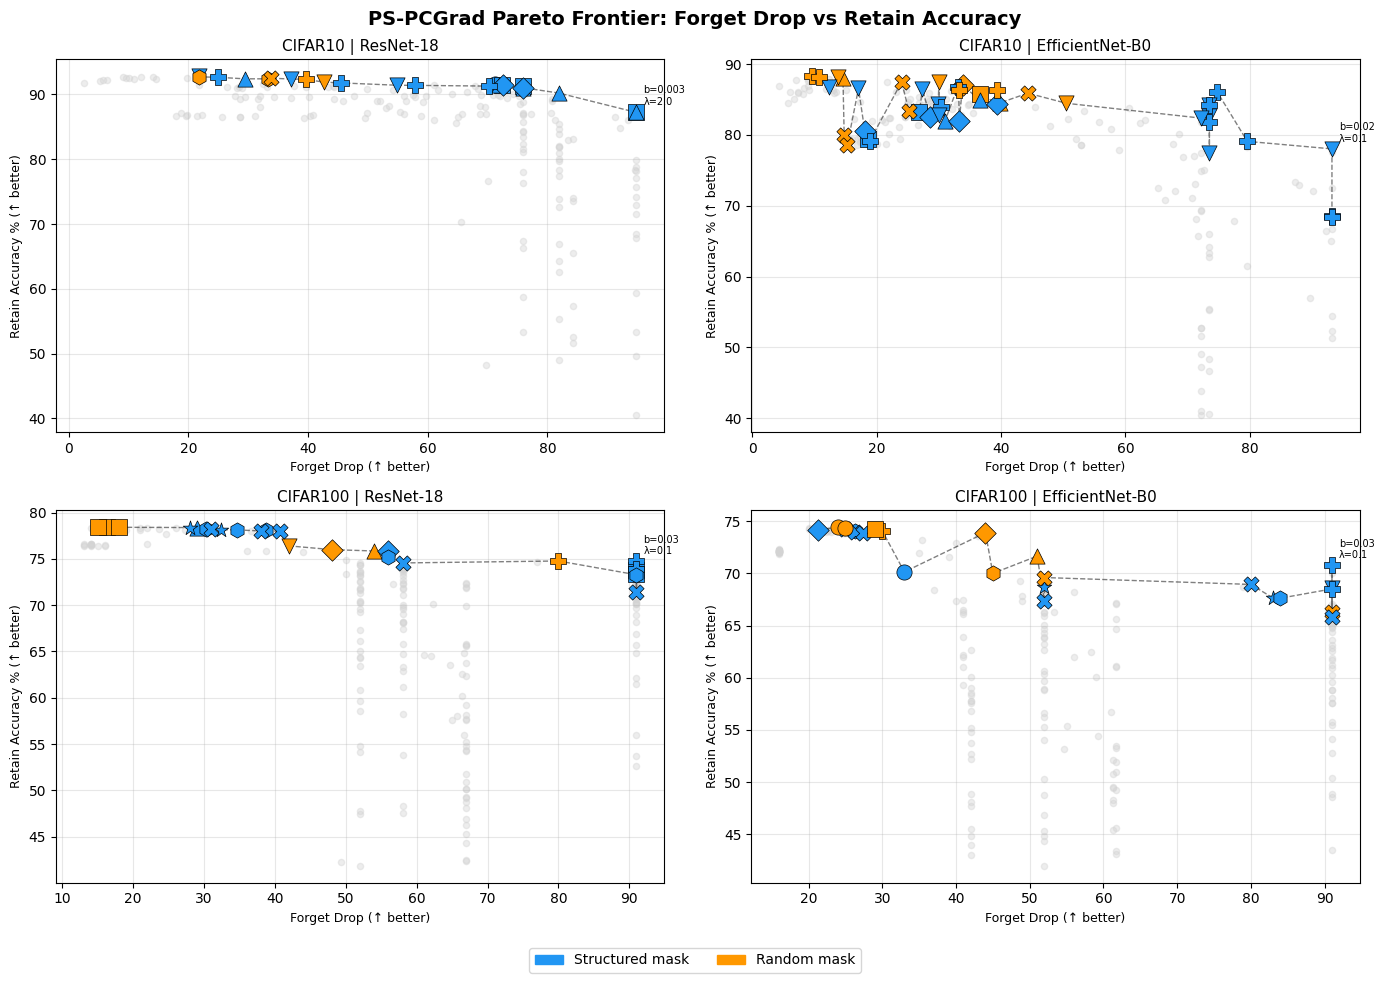

Saved pareto_2d_forget_retain.png


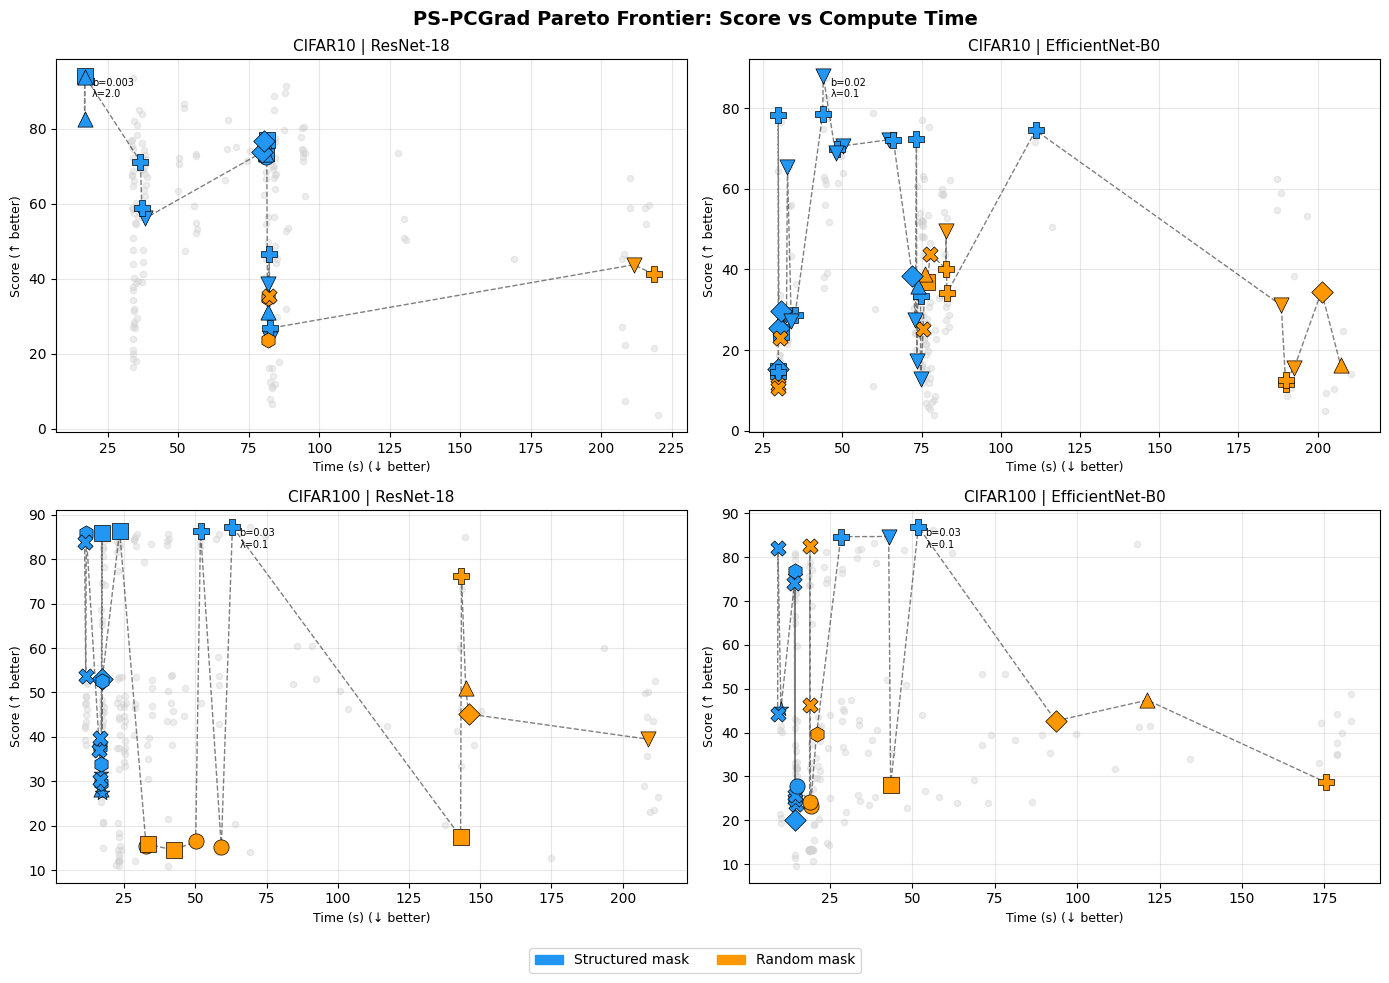

Saved pareto_2d_score_time.png


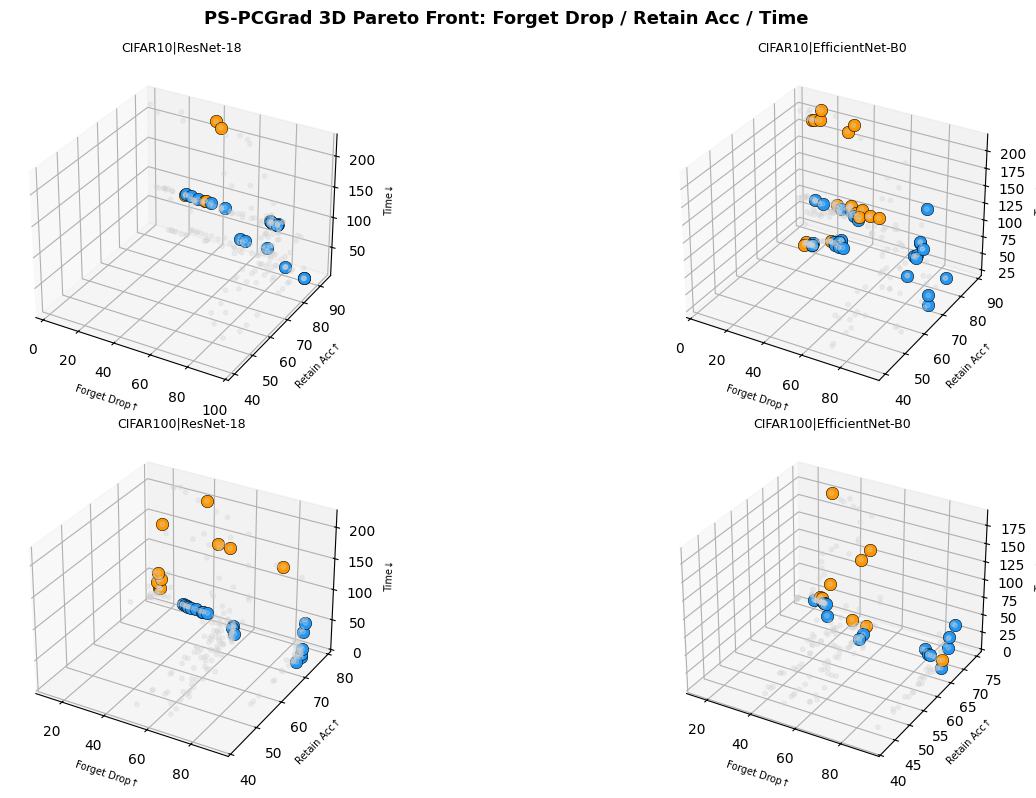

Saved pareto_3d.png


In [ ]:
# ============================================================
# PARETO ANALYSIS — PS-PCGrad
# Assumes: ablation_combined_final.csv exists at CSV_PATH
# Generates: Pareto frontier tables + 2D plots
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_PATH)
ps = df[df['method']=='PS-PCGrad'].dropna(
    subset=['forget_acc','retain_acc','score','time_s']).copy()

# Pareto objectives:
# - Maximize: forget_drop  (higher = more forgotten)
# - Maximize: retain_acc   (higher = less damage)
# - Minimize: time_s       (lower = more efficient)

def is_pareto(costs):
    """
    costs: array of shape (n, k) — each row is one config,
           each col is one objective (all to be MINIMIZED).
    Returns boolean array — True if config is non-dominated.
    """
    n = costs.shape[0]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            # j dominates i if j is <= i on all objectives
            # and strictly < on at least one
            if np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                dominated[i] = True
                break
    return ~dominated

def get_pareto_front(grp):
    """Return Pareto-optimal rows from a group."""
    # Convert to minimization:
    # forget_drop → negate (maximize)
    # retain_acc  → negate (maximize)
    # time_s      → keep   (minimize)
    costs = np.column_stack([
        -grp['forget_drop'].values,
        -grp['retain_acc'].values,
         grp['time_s'].values
    ])
    mask = is_pareto(costs)
    return grp[mask]

# ── TABLE: Pareto frontier per (dataset, arch) ────────────────
print("=" * 70)
print("PARETO FRONTIER CONFIGS — PS-PCGrad")
print("Non-dominated over (forget_drop↑, retain_acc↑, time_s↓)")
print("=" * 70)

pareto_rows = []
for (ds, arch), grp in ps.groupby(['data_set','arch']):
    front = get_pareto_front(grp)
    front_sorted = front.sort_values('forget_drop', ascending=False)
    print(f"\n{ds} | {arch} — {len(front)} non-dominated configs")
    cols = ['forget_cls','budget_b','lambda','mask_mode',
            'forget_acc','retain_acc','score','time_s']
    print(front_sorted[cols].to_string(index=False))
    for _, row in front_sorted.iterrows():
        pareto_rows.append({
            'data_set': ds, 'arch': arch,
            'forget_cls': row['forget_cls'],
            'budget_b': row['budget_b'],
            'lambda': row['lambda'],
            'mask_mode': row['mask_mode'],
            'forget_drop': row['forget_drop'],
            'retain_acc': row['retain_acc'],
            'score': row['score'],
            'time_s': row['time_s'],
        })
# ROOT = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'

pareto_df = pd.DataFrame(pareto_rows)
pareto_df.to_csv(f'{RESULTS_FOLDER}/pareto_frontier.csv', index=False)
print(f"\nSaved → {RESULTS_FOLDER}/pareto_frontier.csv")


# ── PLOT 1: 2D Pareto — forget_drop vs retain_acc ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PS-PCGrad Pareto Frontier: Forget Drop vs Retain Accuracy',
             fontsize=14, fontweight='bold')

combos = [('CIFAR10','ResNet-18'),('CIFAR10','EfficientNet-B0'),
          ('CIFAR100','ResNet-18'),('CIFAR100','EfficientNet-B0')]
colors  = {'structured':'#2196F3','random':'#FF9800'}
markers = {0.001:'o',0.003:'s',0.005:'^',0.010:'D',
           0.020:'v',0.030:'P',0.050:'*',0.100:'h',0.250:'X'}

for ax, (ds, arch) in zip(axes.flatten(), combos):
    grp  = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front= get_pareto_front(grp)

    # All points (background)
    ax.scatter(grp['forget_drop'], grp['retain_acc'],
               c='lightgrey', s=20, alpha=0.4, zorder=1, label='All configs')

    # Pareto front points
    for _, r in front.iterrows():
        c = colors.get(r['mask_mode'], 'grey')
        m = markers.get(round(r['budget_b'],3), 'o')
        ax.scatter(r['forget_drop'], r['retain_acc'],
                   c=c, s=120, marker=m, zorder=3,
                   edgecolors='black', linewidths=0.5)

    # Connect Pareto front
    front_s = front.sort_values('forget_drop')
    ax.plot(front_s['forget_drop'], front_s['retain_acc'],
            'k--', linewidth=1, alpha=0.5, zorder=2)

    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Forget Drop (↑ better)', fontsize=9)
    ax.set_ylabel('Retain Accuracy % (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate best score on Pareto
    best = front.loc[front['score'].idxmax()]
    ax.annotate(f"b={best['budget_b']}\nλ={best['lambda']}",
                xy=(best['forget_drop'], best['retain_acc']),
                xytext=(5, 5), textcoords='offset points', fontsize=7)

# Legend
patch_s = mpatches.Patch(color='#2196F3', label='Structured mask')
patch_r = mpatches.Patch(color='#FF9800', label='Random mask')
fig.legend(handles=[patch_s, patch_r], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{RESULTS_FOLDER}/pareto_2d_forget_retain.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pareto_2d_forget_retain.png")


# ── PLOT 2: 2D Pareto — score vs time ─────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('PS-PCGrad Pareto Frontier: Score vs Compute Time',
              fontsize=14, fontweight='bold')

for ax, (ds, arch) in zip(axes2.flatten(), combos):
    grp  = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front= get_pareto_front(grp)

    ax.scatter(grp['time_s'], grp['score'],
               c='lightgrey', s=20, alpha=0.4, zorder=1)

    for _, r in front.iterrows():
        c = colors.get(r['mask_mode'], 'grey')
        m = markers.get(round(r['budget_b'],3), 'o')
        ax.scatter(r['time_s'], r['score'],
                   c=c, s=120, marker=m, zorder=3,
                   edgecolors='black', linewidths=0.5)

    front_s = front.sort_values('time_s')
    ax.plot(front_s['time_s'], front_s['score'],
            'k--', linewidth=1, alpha=0.5)

    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Time (s) (↓ better)', fontsize=9)
    ax.set_ylabel('Score (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

    best = front.loc[front['score'].idxmax()]
    ax.annotate(f"b={best['budget_b']}\nλ={best['lambda']}",
                xy=(best['time_s'], best['score']),
                xytext=(5,-15), textcoords='offset points', fontsize=7)

fig2.legend(handles=[patch_s, patch_r], loc='lower center',
            ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{RESULTS_FOLDER}/pareto_2d_score_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pareto_2d_score_time.png")


# ── PLOT 3: 3D Pareto — forget, retain, time ──────────────────
fig3 = plt.figure(figsize=(16, 8))
fig3.suptitle('PS-PCGrad 3D Pareto Front: Forget Drop / Retain Acc / Time',
              fontsize=13, fontweight='bold')

for idx, (ds, arch) in enumerate(combos):
    ax = fig3.add_subplot(2, 2, idx+1, projection='3d')
    grp  = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front= get_pareto_front(grp)

    ax.scatter(grp['forget_drop'], grp['retain_acc'], grp['time_s'],
               c='lightgrey', s=10, alpha=0.3)
    for _, r in front.iterrows():
        c = colors.get(r['mask_mode'], 'grey')
        ax.scatter(r['forget_drop'], r['retain_acc'], r['time_s'],
                   c=c, s=80, edgecolors='black', linewidths=0.4)

    ax.set_xlabel('Forget Drop↑', fontsize=7)
    ax.set_ylabel('Retain Acc↑', fontsize=7)
    ax.set_zlabel('Time↓', fontsize=7)
    ax.set_title(f'{ds}|{arch}', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/pareto_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pareto_3d.png")

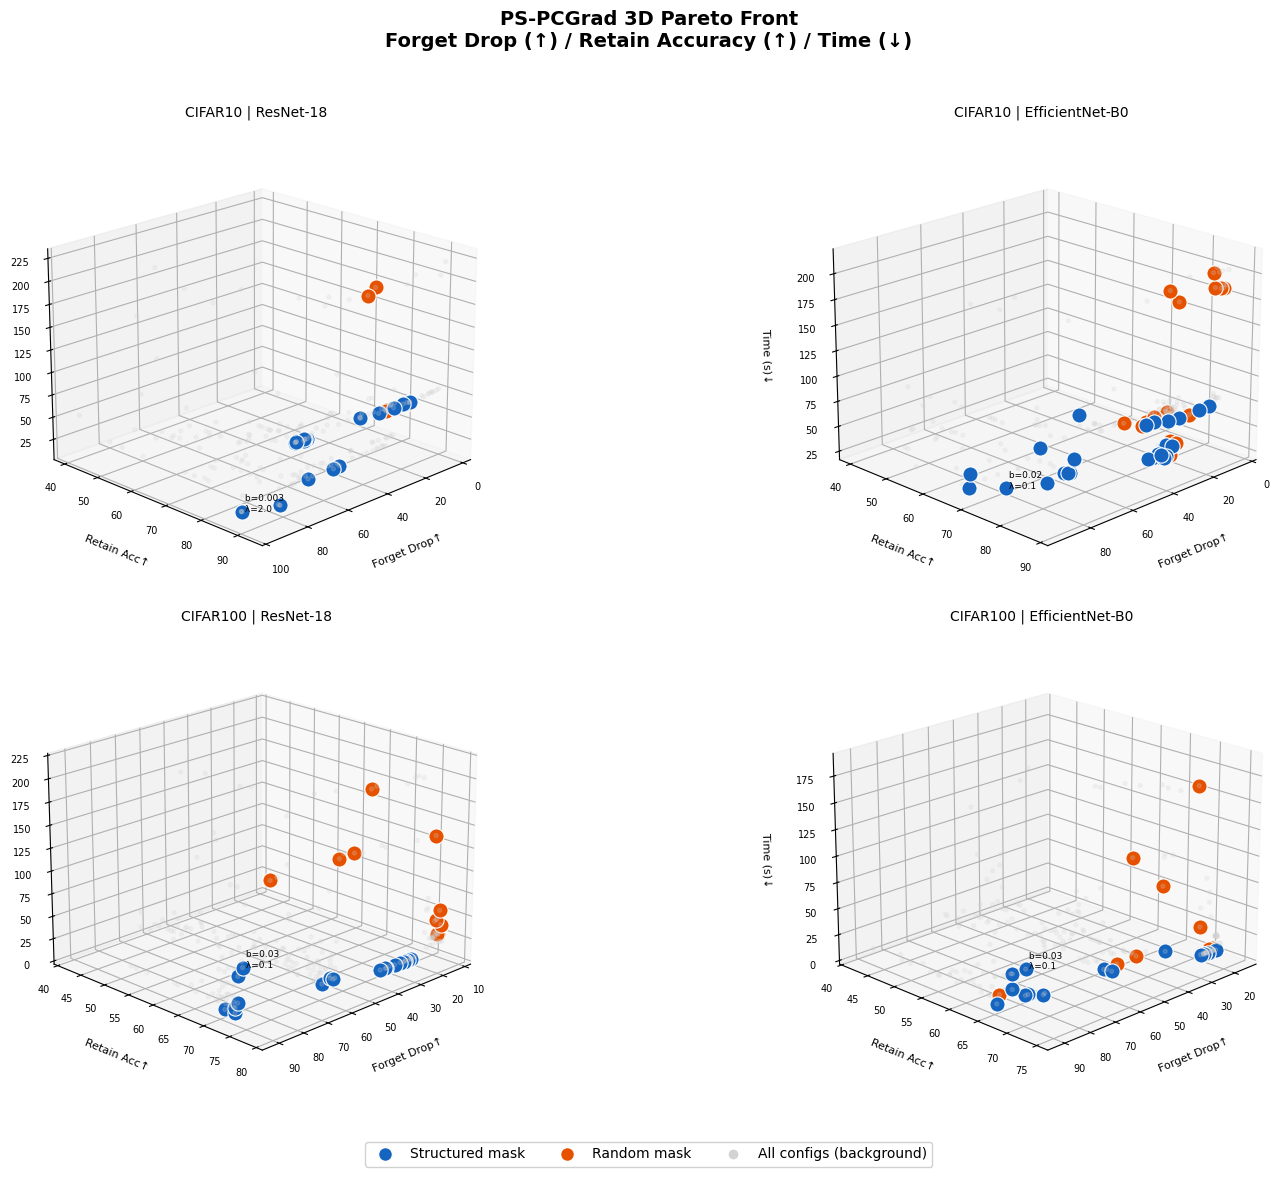

In [ ]:
# fig3 = plt.figure(figsize=(18, 12))
# fig3.suptitle('PS-PCGrad 3D Pareto Front\nForget Drop (↑) / Retain Accuracy (↑) / Time (↓)',
#               fontsize=14, fontweight='bold', y=0.98)

# for idx, (ds, arch) in enumerate(combos):
#     ax = fig3.add_subplot(2, 2, idx+1, projection='3d')
#     grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
#     front = get_pareto_front(grp)

#     # Background — all configs
#     ax.scatter(grp['forget_drop'], grp['retain_acc'], grp['time_s'],
#                c='lightgrey', s=8, alpha=0.2, zorder=1, depthshade=True)

#     # Pareto front — split by mask
#     for mask_type, col in [('structured','#1565C0'), ('random','#E65100')]:
#         sub = front[front['mask_mode']==mask_type]
#         if len(sub) == 0: continue
#         ax.scatter(sub['forget_drop'], sub['retain_acc'], sub['time_s'],
#                    c=col, s=120, edgecolors='white', linewidths=0.8,
#                    zorder=5, depthshade=False,
#                    label=f'{mask_type} mask')

#     # Annotate the single best score point
#     if len(front) > 0:
#         best = front.loc[front['score'].idxmax()]
#         ax.text(best['forget_drop'], best['retain_acc'], best['time_s'],
#                 f" b={best['budget_b']}\n λ={best['lambda']}",
#                 fontsize=6.5, color='black', zorder=6)

#     ax.set_xlabel('Forget Drop↑', fontsize=8, labelpad=8)
#     ax.set_ylabel('Retain Acc↑',  fontsize=8, labelpad=8)
#     ax.set_zlabel('Time (s)↓',    fontsize=8, labelpad=8)
#     ax.set_title(f'{ds} | {arch}', fontsize=10, pad=10)
#     ax.tick_params(labelsize=7)

#     # Better viewing angle
#     ax.view_init(elev=20, azim=45)

# # Single shared legend
# handles = [
#     plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565C0',
#                markersize=10, label='Structured mask'),
#     plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#E65100',
#                markersize=10, label='Random mask'),
#     plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightgrey',
#                markersize=8, label='All configs (background)'),
# ]
# fig3.legend(handles=handles, loc='lower center', ncol=3,
#             fontsize=10, bbox_to_anchor=(0.5, 0.01),
#             framealpha=0.9)

# plt.tight_layout(rect=[0, 0.06, 1, 0.96])
# plt.savefig(f'{ROOT}/pareto_3d.png', dpi=180, bbox_inches='tight')
# plt.show()

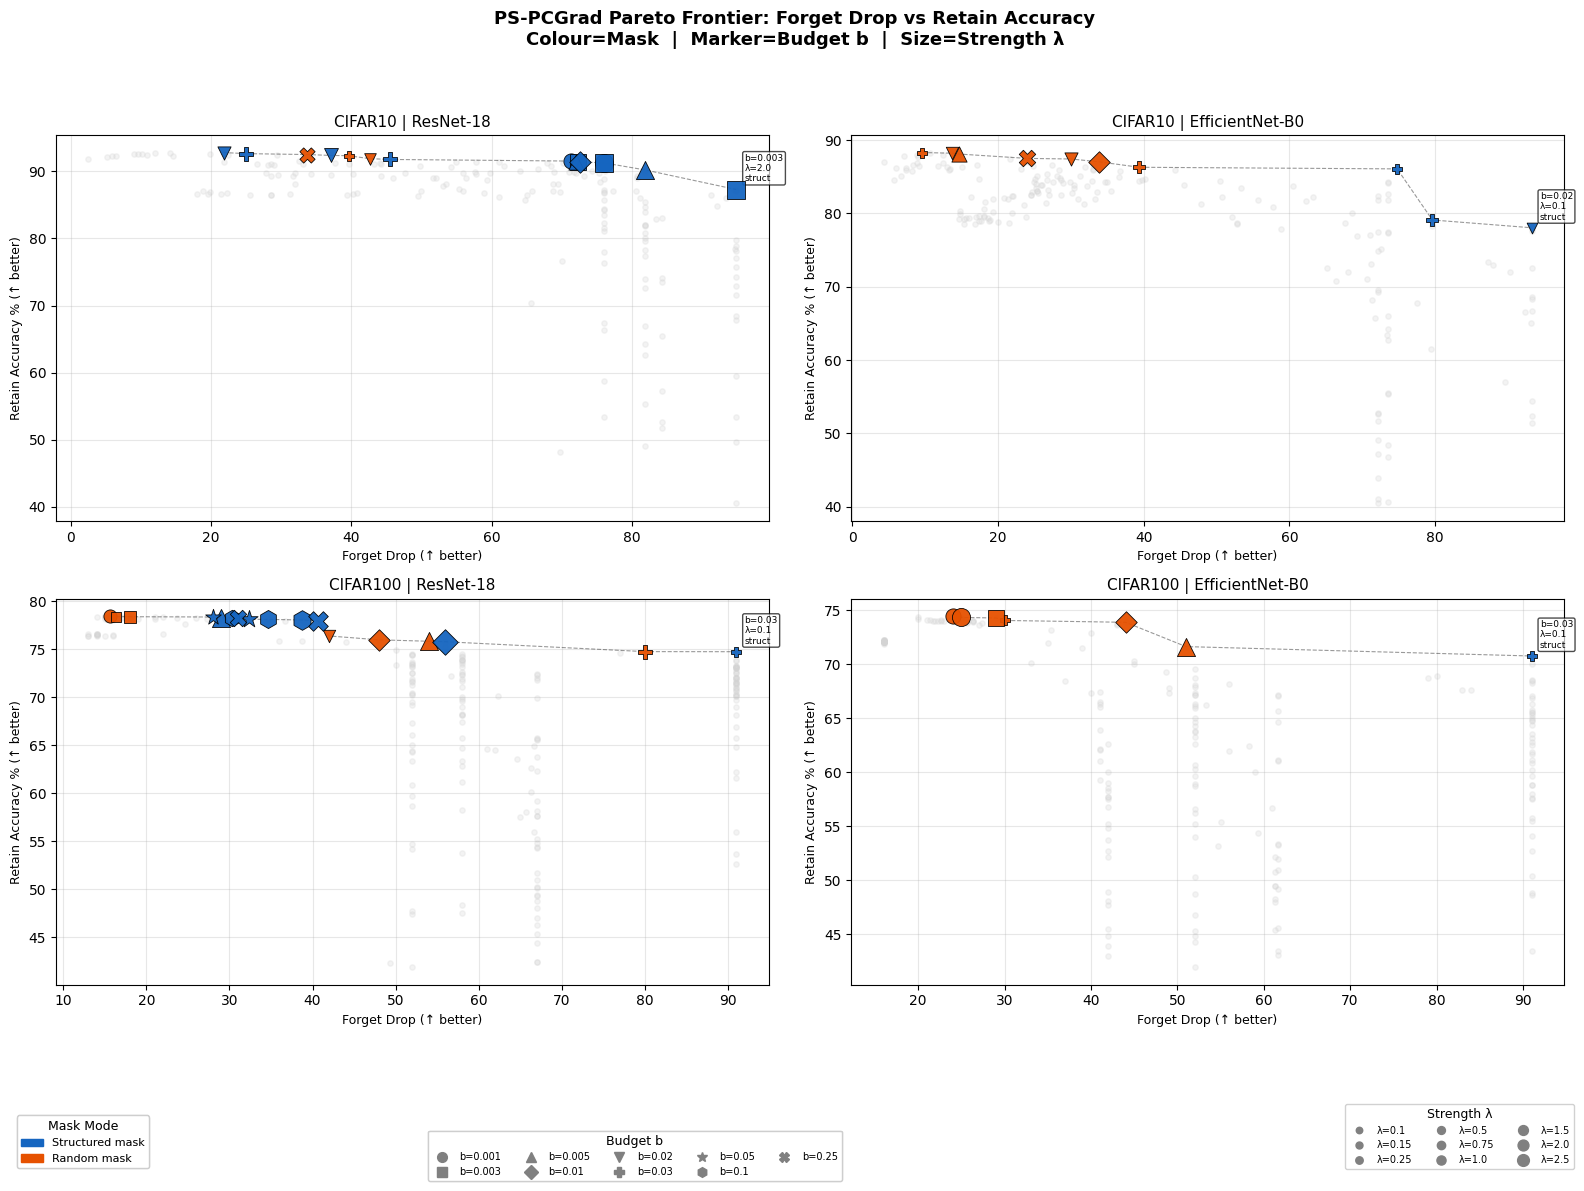

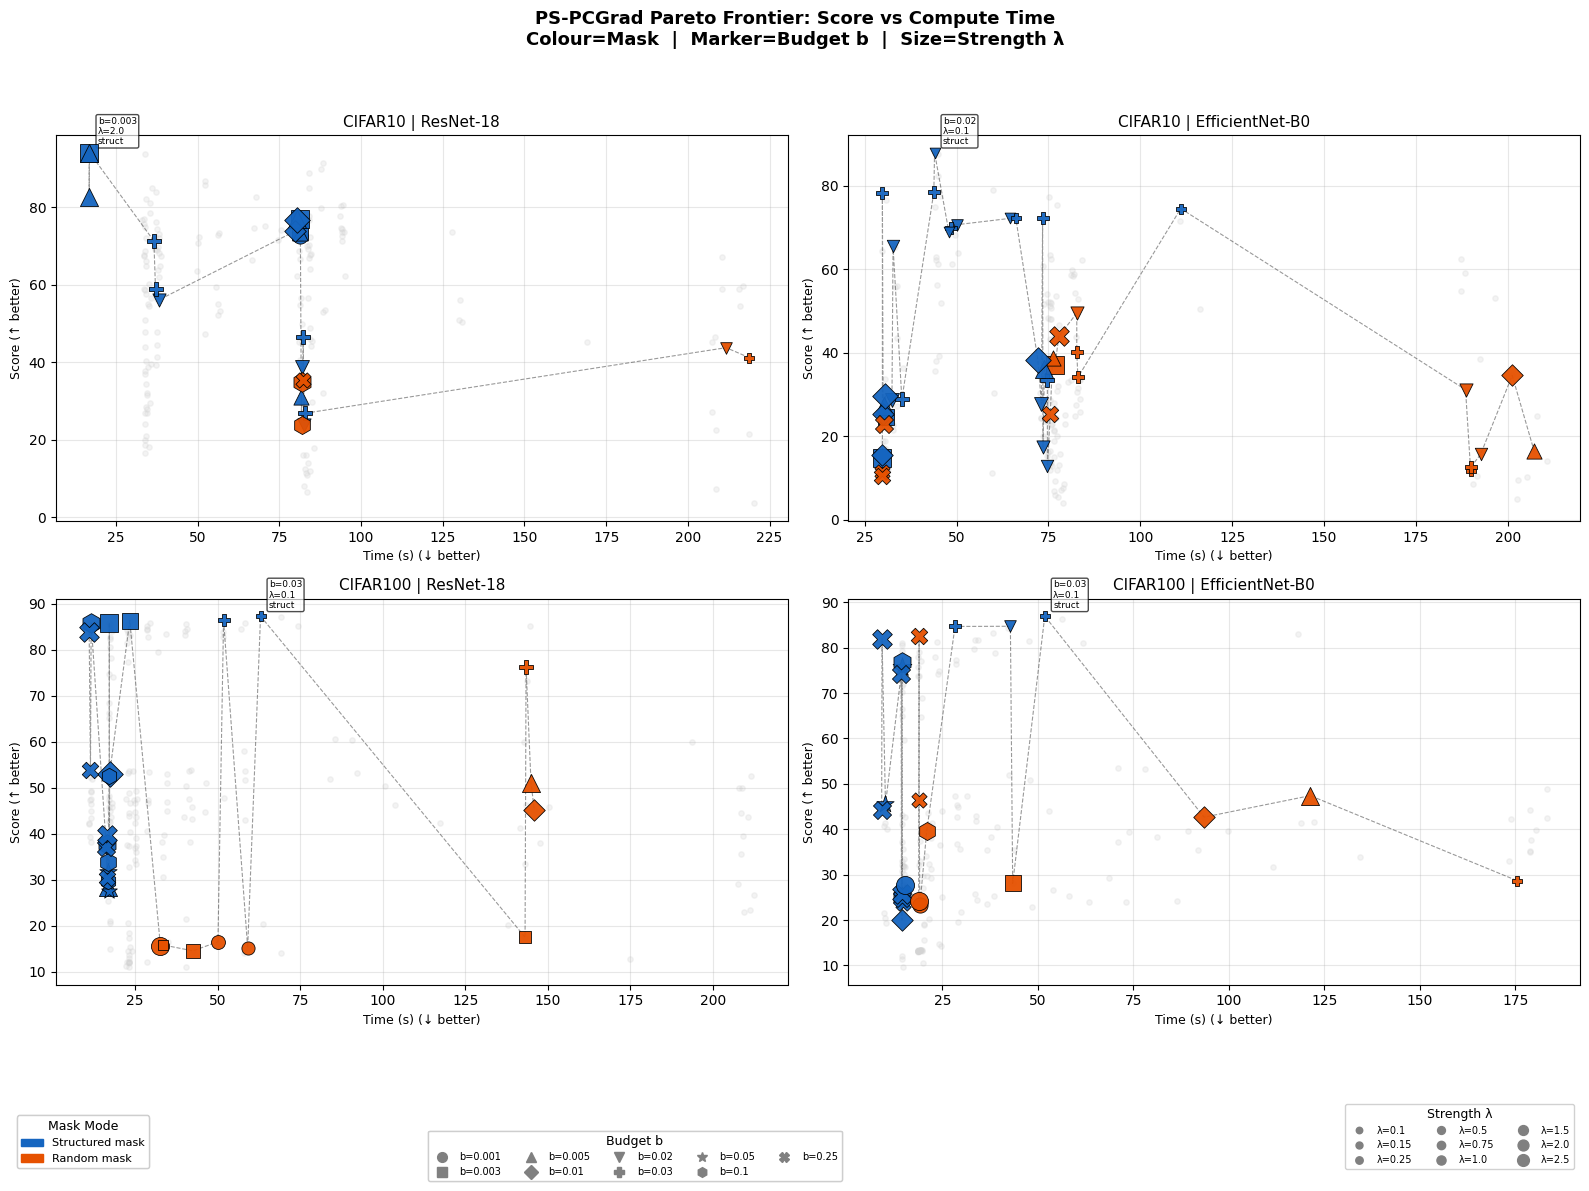

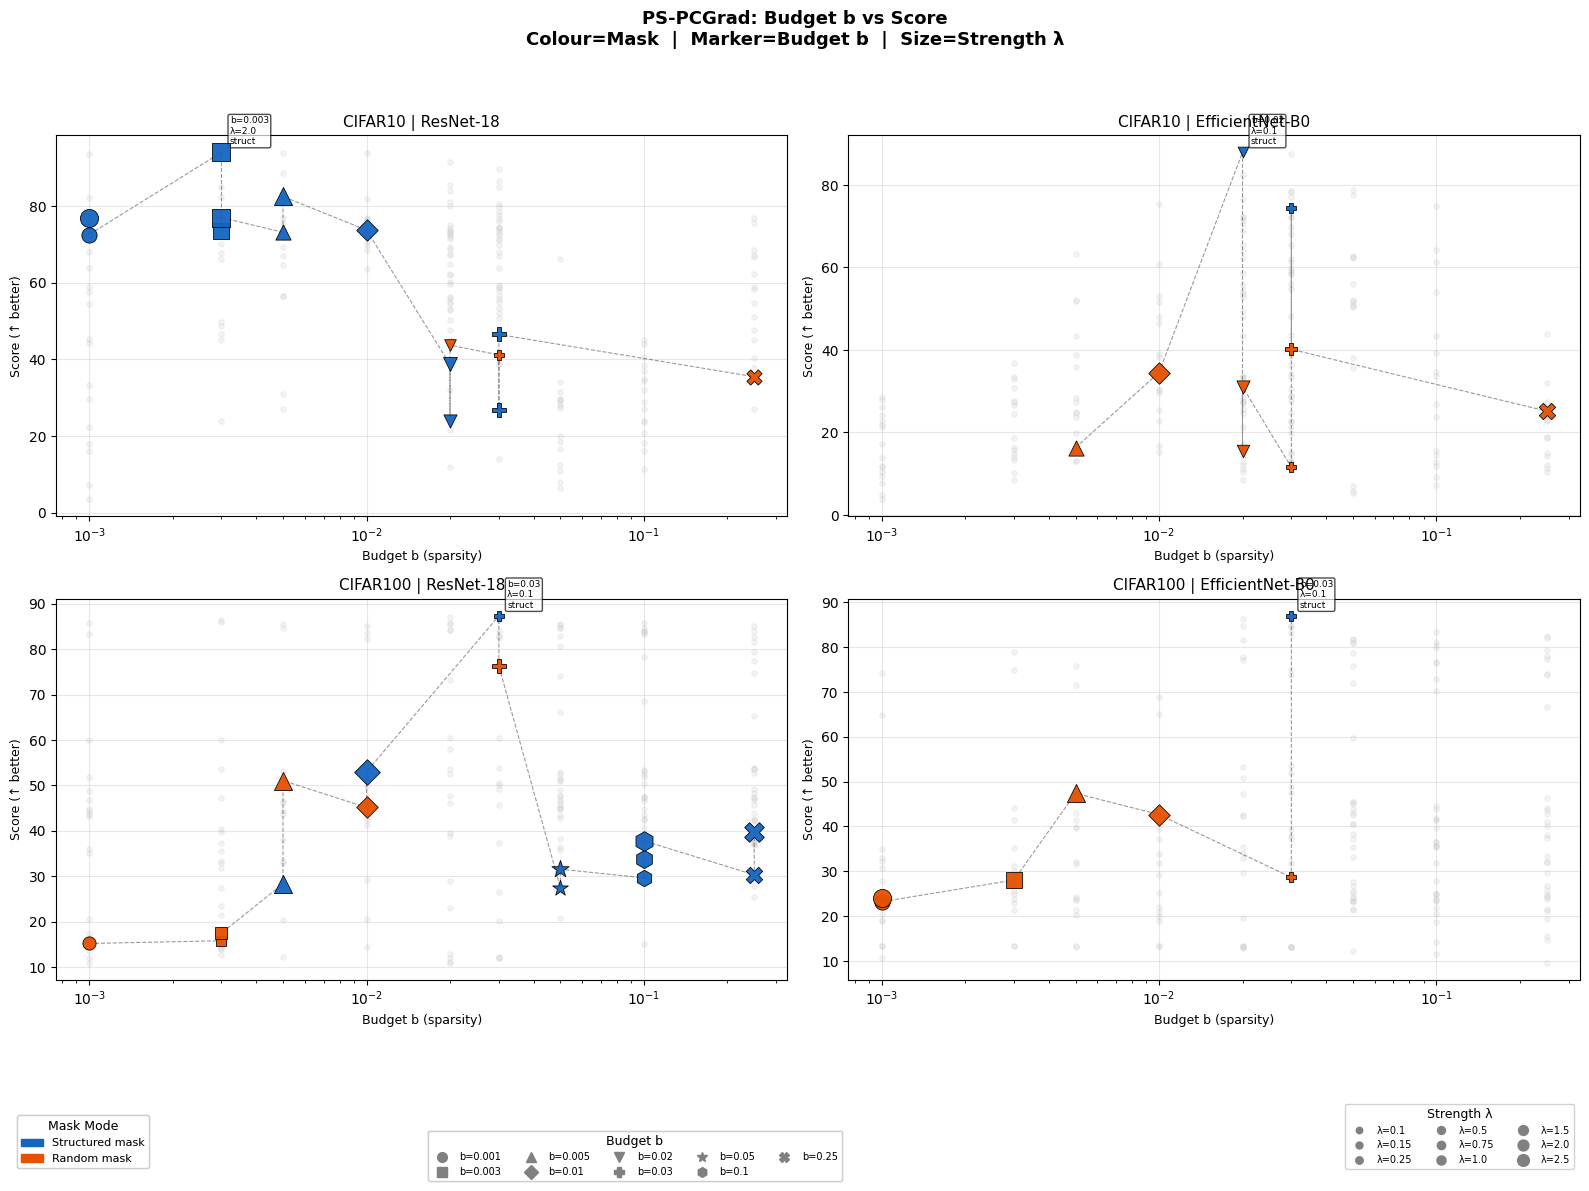

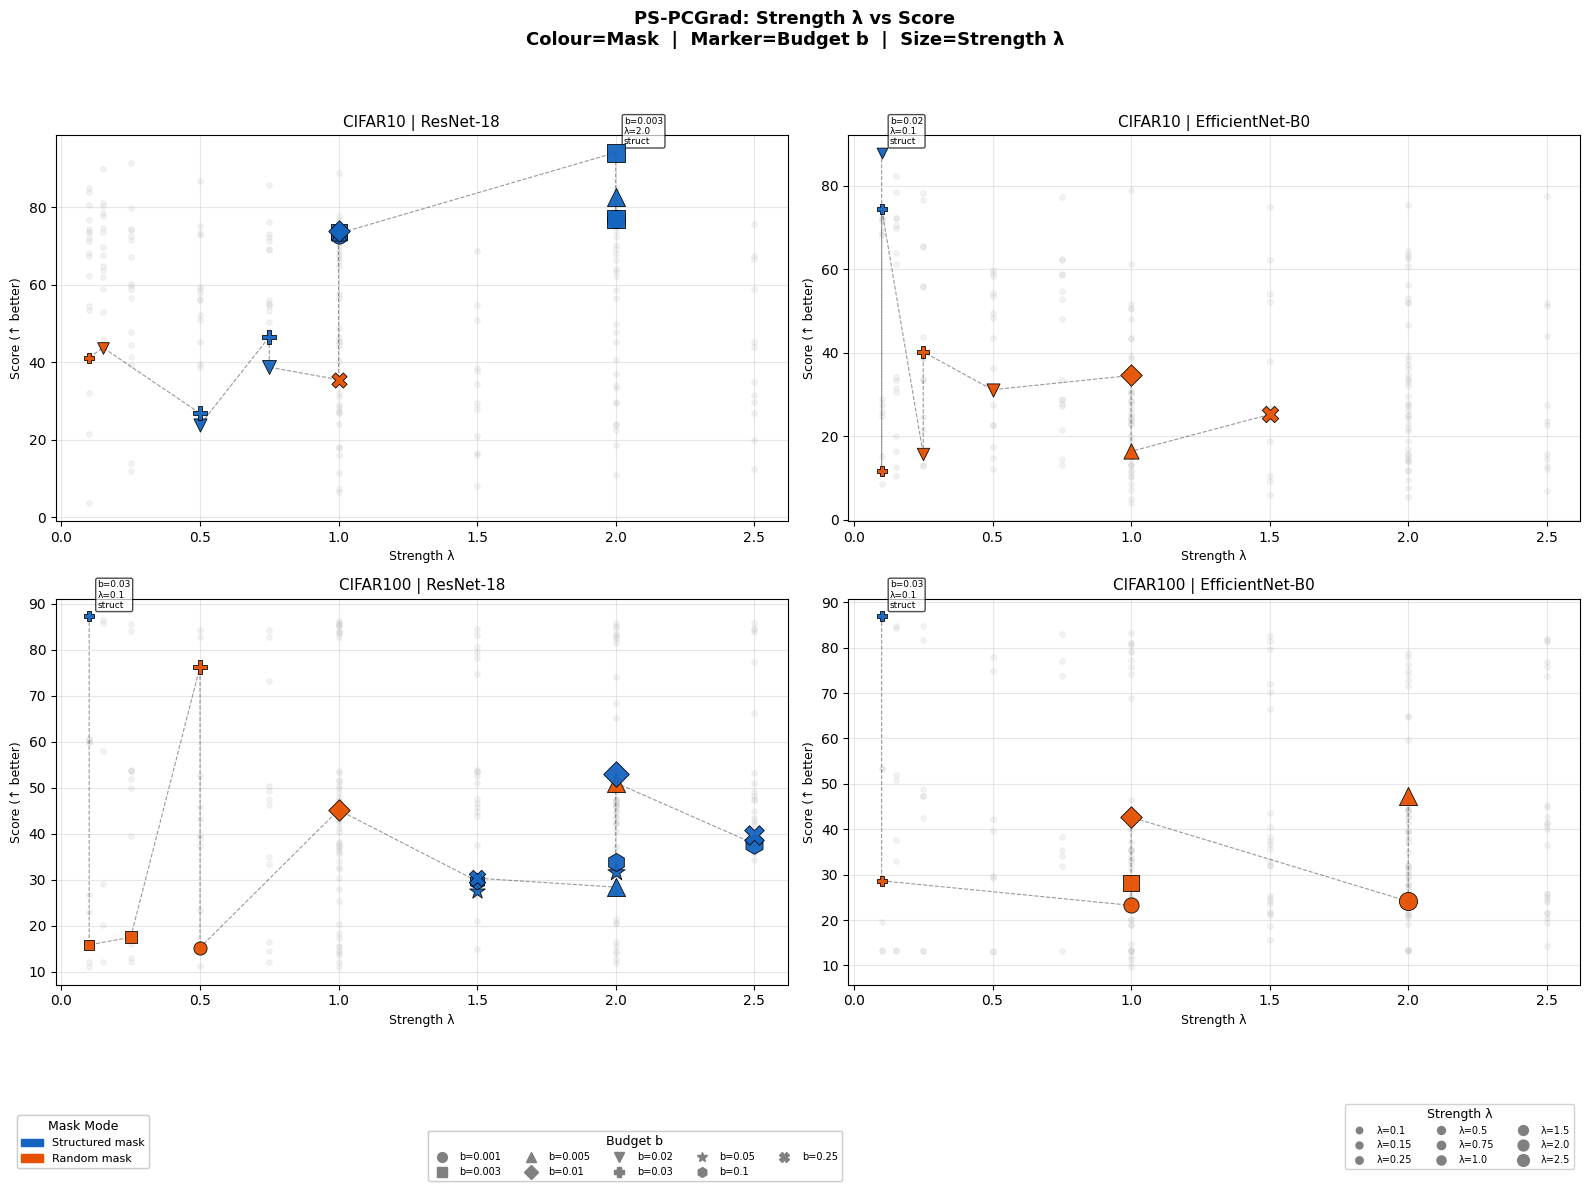

In [ ]:
# ============================================================
# PARETO ANALYSIS — Full parameter encoding
# Colour  = mask mode (structured/random)
# Marker  = budget b
# Size    = strength λ
# ============================================================

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Load combined CSV ─────────────────────────────────────────
df = pd.read_csv(OUTPUT_PATH)
ps = df[df['method']=='PS-PCGrad'].dropna(
    subset=['forget_acc','retain_acc','score','time_s',
            'forget_drop','retain_drop']).copy()

# ── Pareto helper ─────────────────────────────────────────────


# ── Shared legend function ────────────────────────────────────
def _add_legend(fig):
    # Mask colour
    patch_s = mpatches.Patch(color='#1565C0', label='Structured mask')
    patch_r = mpatches.Patch(color='#E65100', label='Random mask')

    # Budget markers
    budget_handles = [
        mlines.Line2D([],[],marker=m, color='grey', linestyle='None',
                      markersize=7, label=f'b={b}')
        for b, m in sorted(MARKER_MAP.items())
    ]

    # Strength sizes
    str_handles = [
        mlines.Line2D([],[],marker='o', color='grey', linestyle='None',
                      markersize=np.sqrt(s)*0.6, label=f'λ={lam}')
        for lam, s in sorted(SIZE_MAP.items())
    ]

    # Three legend groups
    leg1 = fig.legend(handles=[patch_s, patch_r],
                      title='Mask Mode', loc='lower left',
                      bbox_to_anchor=(0.01, 0.01), fontsize=8,
                      title_fontsize=9, framealpha=0.9)
    leg2 = fig.legend(handles=budget_handles,
                      title='Budget b', loc='lower center',
                      bbox_to_anchor=(0.40, 0.00), fontsize=7,
                      ncol=5, title_fontsize=9, framealpha=0.9)
    leg3 = fig.legend(handles=str_handles,
                      title='Strength λ', loc='lower right',
                      bbox_to_anchor=(0.99, 0.01), fontsize=7,
                      ncol=3, title_fontsize=9, framealpha=0.9)
    fig.add_artist(leg1)
    fig.add_artist(leg2)

def is_pareto(costs):
    n = costs.shape[0]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                dominated[i] = True
                break
    return ~dominated

def get_pareto_front(grp, obj1, obj2, obj3=None):
    """
    obj1, obj2: columns to MAXIMISE (negated internally)
    obj3:       column to MINIMISE (optional third axis)
    """
    cols = [-grp[obj1].values, -grp[obj2].values]
    if obj3: cols.append(grp[obj3].values)
    costs = np.column_stack(cols)
    mask  = is_pareto(costs)
    return grp[mask]

# ── Visual encodings ──────────────────────────────────────────
COLOR_MAP = {'structured': '#1565C0', 'random': '#E65100'}

MARKER_MAP = {
    0.001: 'o', 0.003: 's', 0.005: '^', 0.010: 'D',
    0.020: 'v', 0.030: 'P', 0.050: '*', 0.100: 'h', 0.250: 'X'
}

SIZE_MAP = {
    0.10: 60,  0.15: 70,  0.25: 80,  0.50: 90,  0.75: 100,
    1.00: 120, 1.50: 140, 2.00: 170, 2.50: 200
}

def plot_pareto_points(ax, front, all_pts,
                       xcol, ycol, annotate_best=True):
    """Plot all background points + Pareto front with full encoding."""

    # Background — all configs
    ax.scatter(all_pts[xcol], all_pts[ycol],
               c='lightgrey', s=15, alpha=0.25, zorder=1)

    # Pareto front — full encoding
    for _, r in front.iterrows():
        c = COLOR_MAP.get(r['mask_mode'], 'grey')
        m = MARKER_MAP.get(round(r['budget_b'], 3), 'o')
        s = SIZE_MAP.get(round(r['lambda'], 2), 100)
        ax.scatter(r[xcol], r[ycol],
                   c=c, marker=m, s=s,
                   edgecolors='black', linewidths=0.6,
                   zorder=4, alpha=0.95)

    # Connect front with dashed line (sorted by x)
    front_s = front.sort_values(xcol)
    ax.plot(front_s[xcol], front_s[ycol],
            'k--', linewidth=0.8, alpha=0.4, zorder=2)

    # Annotate best score point only
    if annotate_best and len(front) > 0:
        best = front.loc[front['score'].idxmax()]
        ax.annotate(
            f"b={best['budget_b']}\nλ={best['lambda']}\n{best['mask_mode'][:6]}",
            xy=(best[xcol], best[ycol]),
            xytext=(6, 6), textcoords='offset points',
            fontsize=6.5, color='black',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
        )


combos = [
    ('CIFAR10',  'ResNet-18'),
    ('CIFAR10',  'EfficientNet-B0'),
    ('CIFAR100', 'ResNet-18'),
    ('CIFAR100', 'EfficientNet-B0'),
]

# ── PLOT 1: Forget Drop vs Retain Accuracy ────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle(
    'PS-PCGrad Pareto Frontier: Forget Drop vs Retain Accuracy\n'
    'Colour=Mask  |  Marker=Budget b  |  Size=Strength λ',
    fontsize=13, fontweight='bold')

for ax, (ds, arch) in zip(axes1.flatten(), combos):
    grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front = get_pareto_front(grp, 'forget_drop', 'retain_acc')
    plot_pareto_points(ax, front, grp, 'forget_drop', 'retain_acc')
    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Forget Drop (↑ better)', fontsize=9)
    ax.set_ylabel('Retain Accuracy % (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
_add_legend(fig1)
plt.savefig(f'{ROOT}/pareto_forget_retain_full.png', dpi=180, bbox_inches='tight')
plt.show()


# ── PLOT 2: Score vs Time ─────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle(
    'PS-PCGrad Pareto Frontier: Score vs Compute Time\n'
    'Colour=Mask  |  Marker=Budget b  |  Size=Strength λ',
    fontsize=13, fontweight='bold')

for ax, (ds, arch) in zip(axes2.flatten(), combos):
    grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front = get_pareto_front(grp, 'score', 'retain_acc', obj3='time_s')
    plot_pareto_points(ax, front, grp, 'time_s', 'score')
    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Time (s) (↓ better)', fontsize=9)
    ax.set_ylabel('Score (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
_add_legend(fig2)
plt.savefig(f'{ROOT}/pareto_score_time_full.png', dpi=180, bbox_inches='tight')
plt.show()


# ── PLOT 3: Budget b vs Score (coloured by strength) ─────────
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
fig3.suptitle(
    'PS-PCGrad: Budget b vs Score\n'
    'Colour=Mask  |  Marker=Budget b  |  Size=Strength λ',
    fontsize=13, fontweight='bold')

for ax, (ds, arch) in zip(axes3.flatten(), combos):
    grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front = get_pareto_front(grp, 'score', 'retain_acc')
    plot_pareto_points(ax, front, grp, 'budget_b', 'score')
    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Budget b (sparsity)', fontsize=9)
    ax.set_ylabel('Score (↑ better)', fontsize=9)
    ax.set_xscale('log')   # log scale makes b values readable
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
_add_legend(fig3)
plt.savefig(f'{ROOT}/pareto_budget_score_full.png', dpi=180, bbox_inches='tight')
plt.show()


# ── PLOT 4: Strength λ vs Score ───────────────────────────────
fig4, axes4 = plt.subplots(2, 2, figsize=(16, 12))
fig4.suptitle(
    'PS-PCGrad: Strength λ vs Score\n'
    'Colour=Mask  |  Marker=Budget b  |  Size=Strength λ',
    fontsize=13, fontweight='bold')

for ax, (ds, arch) in zip(axes4.flatten(), combos):
    grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front = get_pareto_front(grp, 'score', 'retain_acc')
    plot_pareto_points(ax, front, grp, 'lambda', 'score')
    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Strength λ', fontsize=9)
    ax.set_ylabel('Score (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
_add_legend(fig4)
plt.savefig(f'{ROOT}/pareto_strength_score_full.png', dpi=180, bbox_inches='tight')
plt.show()


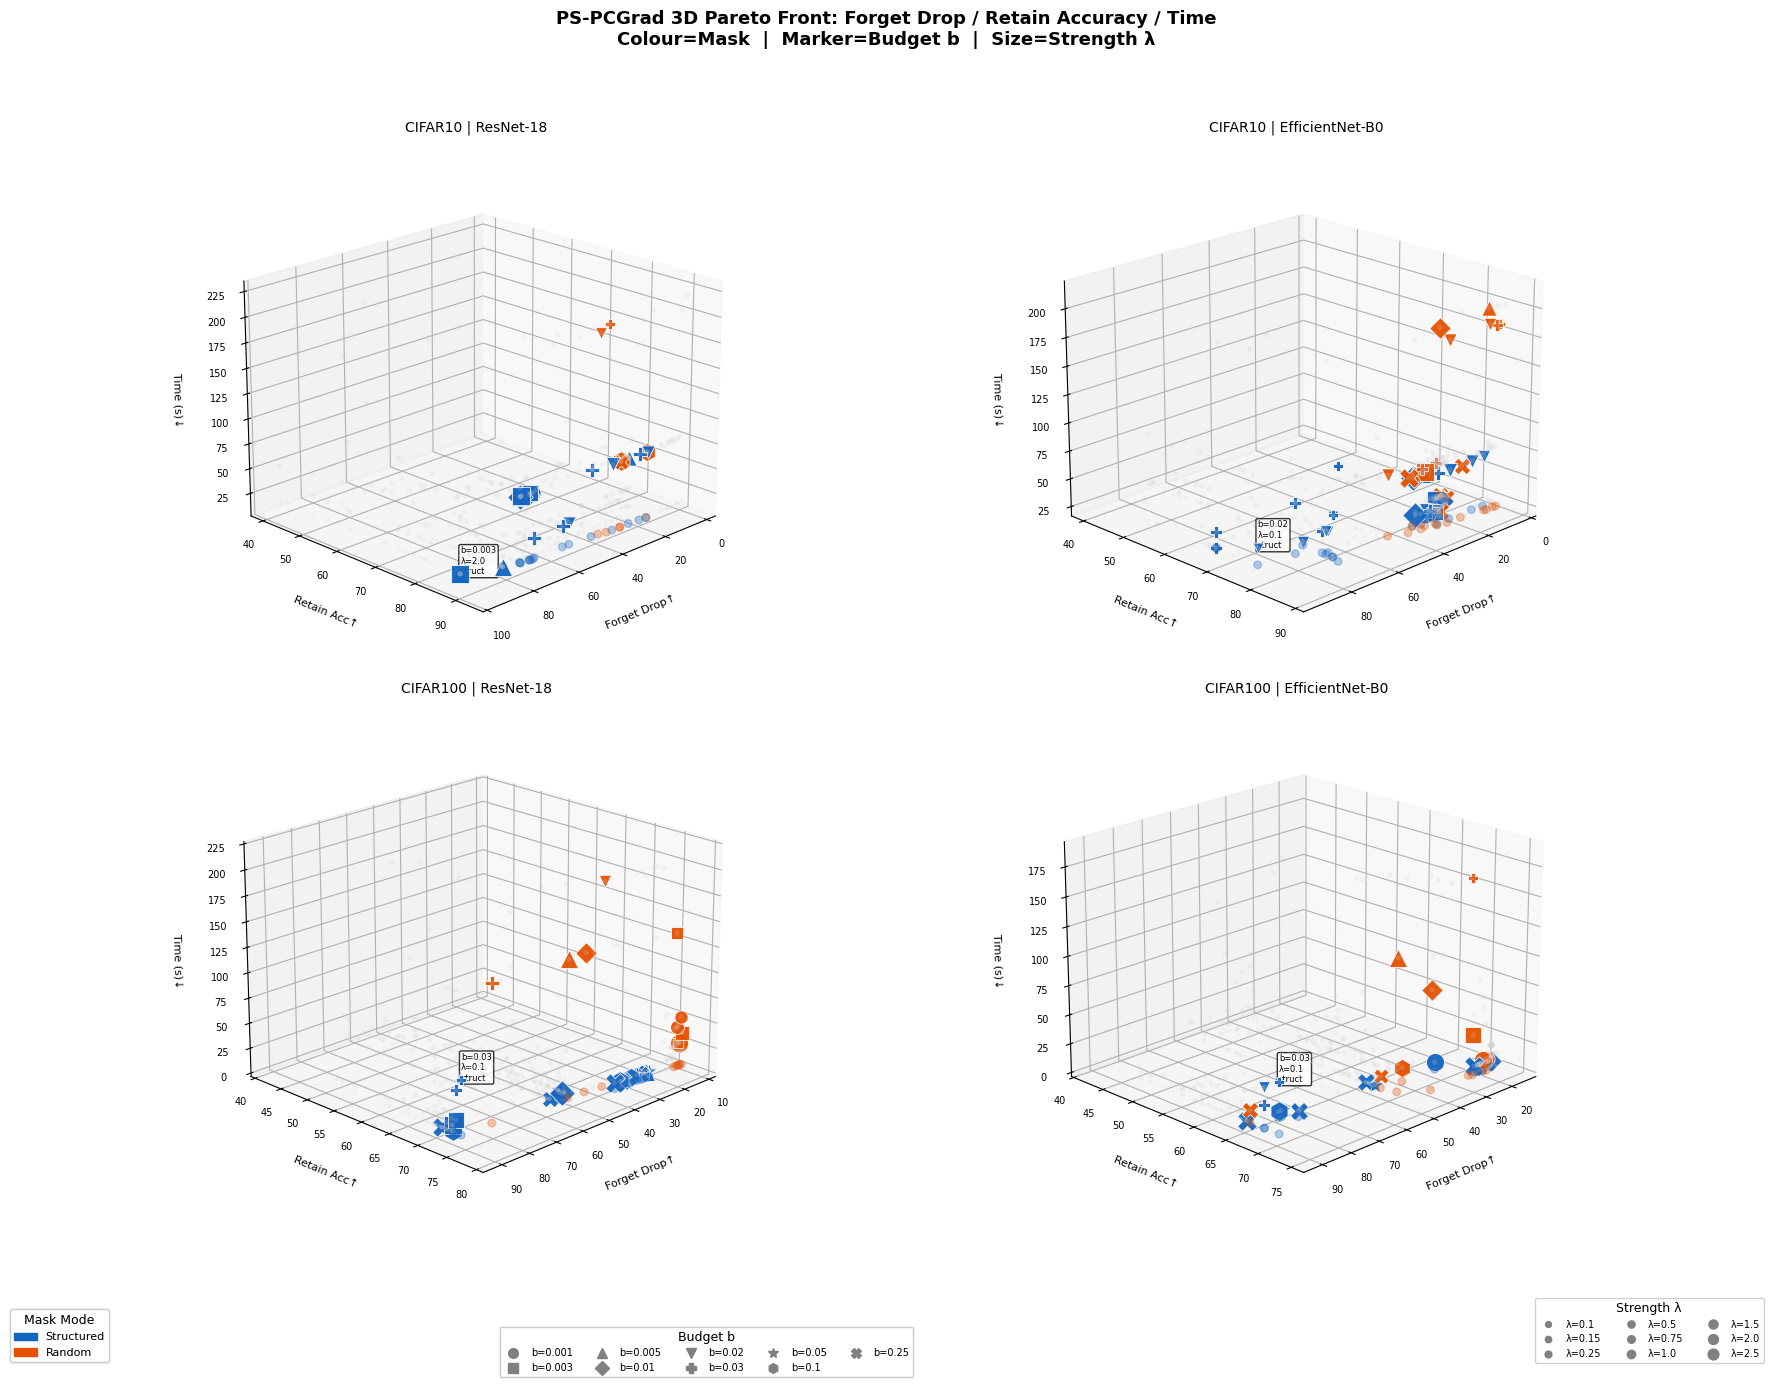

Saved → /content/drive/MyDrive/unlearning_project/ARTIFACTS/pareto_3d_full.png


In [ ]:
# ============================================================
# PARETO 3D — Forget Drop / Retain Accuracy / Time
# Colour = mask mode | Marker = budget b | Size = strength λ
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

fig3d, axes3d = plt.subplots(2, 2, figsize=(18, 14),
                              subplot_kw={'projection': '3d'})
fig3d.suptitle(
    'PS-PCGrad 3D Pareto Front: Forget Drop / Retain Accuracy / Time\n'
    'Colour=Mask  |  Marker=Budget b  |  Size=Strength λ',
    fontsize=13, fontweight='bold')

for ax, (ds, arch) in zip(axes3d.flatten(), combos):
    grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    front = get_pareto_front(grp, 'forget_drop', 'retain_acc', obj3='time_s')

    # ── Background — all configs ──────────────────────────────
    ax.scatter(grp['forget_drop'], grp['retain_acc'], grp['time_s'],
               c='lightgrey', s=8, alpha=0.15, zorder=1, depthshade=True)

    # ── Pareto front — full encoding ──────────────────────────
    for _, r in front.iterrows():
        c = COLOR_MAP.get(r['mask_mode'], 'grey')
        m = MARKER_MAP.get(round(r['budget_b'], 3), 'o')
        s = SIZE_MAP.get(round(r['lambda'], 2), 100)
        ax.scatter(r['forget_drop'], r['retain_acc'], r['time_s'],
                   c=c, marker=m, s=s,
                   edgecolors='white', linewidths=0.6,
                   zorder=5, depthshade=False, alpha=0.95)

    # ── Annotate best score point only ────────────────────────
    if len(front) > 0:
        best = front.loc[front['score'].idxmax()]
        ax.text(best['forget_drop'], best['retain_acc'], best['time_s'],
                f"b={best['budget_b']}\nλ={best['lambda']}\n{best['mask_mode'][:6]}",
                fontsize=6, color='black', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    # ── Project shadows on floor (helps depth perception) ─────
    ax.scatter(grp['forget_drop'], grp['retain_acc'],
               zs=grp['time_s'].min(), zdir='z',
               c='lightgrey', s=4, alpha=0.1, zorder=0)
    ax.scatter(front['forget_drop'], front['retain_acc'],
               zs=front['time_s'].min(), zdir='z',
               c=[COLOR_MAP.get(m,'grey') for m in front['mask_mode']],
               s=30, alpha=0.3, zorder=2)

    # ── Axis labels and formatting ────────────────────────────
    ax.set_xlabel('Forget Drop↑',  fontsize=8, labelpad=8)
    ax.set_ylabel('Retain Acc↑',   fontsize=8, labelpad=8)
    ax.set_zlabel('Time (s)↓',     fontsize=8, labelpad=8)
    ax.set_title(f'{ds} | {arch}', fontsize=10, pad=12)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=20, azim=45)
    ax.grid(True, alpha=0.3)

# ── Legend — three groups ─────────────────────────────────────
# Mask colour
patch_s = mpatches.Patch(color='#1565C0', label='Structured')
patch_r = mpatches.Patch(color='#E65100', label='Random')

# Budget markers
budget_handles = [
    mlines.Line2D([],[],marker=m, color='grey', linestyle='None',
                  markersize=7, label=f'b={b}')
    for b, m in sorted(MARKER_MAP.items())
]

# Strength sizes (shown as circles of different sizes)
str_handles = [
    mlines.Line2D([],[],marker='o', color='grey', linestyle='None',
                  markersize=np.sqrt(s)*0.55, label=f'λ={lam}')
    for lam, s in sorted(SIZE_MAP.items())
]

leg1 = fig3d.legend(handles=[patch_s, patch_r],
                    title='Mask Mode', loc='lower left',
                    bbox_to_anchor=(0.01, 0.01),
                    fontsize=8, title_fontsize=9, framealpha=0.9)
leg2 = fig3d.legend(handles=budget_handles,
                    title='Budget b', loc='lower center',
                    bbox_to_anchor=(0.40, 0.00),
                    fontsize=7, ncol=5,
                    title_fontsize=9, framealpha=0.9)
leg3 = fig3d.legend(handles=str_handles,
                    title='Strength λ', loc='lower right',
                    bbox_to_anchor=(0.99, 0.01),
                    fontsize=7, ncol=3,
                    title_fontsize=9, framealpha=0.9)
fig3d.add_artist(leg1)
fig3d.add_artist(leg2)

plt.tight_layout(rect=[0, 0.10, 1, 0.95])
plt.savefig(f'{ROOT}/pareto_3d_full.png', dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved → {ROOT}/pareto_3d_full.png")